In [2]:
################################################################################
#  MUMBAI HEAT STRESS CLASSIFICATION — Nambiar et al. (2026)
#  IMD Synoptic Data — HI / PET classification
#  EXTENDED: Air Pollution (MPCB 2019-2025) + HAPSI compound index
#
#  MODEL 1 — DNN-CW-BBAG      (thermal only,          IMD 1969-2025)
#  MODEL 2 — DNN-CW-BBAG-POLL (thermal + pollution,   MPCB 2019-2025)
#
#  CELL 1 — Google Colab Setup + Installs + Imports
################################################################################
from google.colab import drive
drive.mount('/content/drive')

!pip install imbalanced-learn shap --quiet

import os, time, gc, warnings
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.optimize import minimize
from scipy.stats import spearmanr
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, ExtraTreesClassifier
)
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, cohen_kappa_score,
    multilabel_confusion_matrix
)
from imblearn.combine import SMOTEENN
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import (
    EasyEnsembleClassifier, RUSBoostClassifier, BalancedBaggingClassifier
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, regularizers

warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Imports done')
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
✅ Imports done
TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
# CELL 2 — Configuration
# ──── CHANGE THESE FOR EACH RUN ────────────────────────────────────────────
STATION_ID = '43057'          # '43057' = Colaba  |  '43003' = Santacruz
STATION    = 'Colaba' if STATION_ID == '43057' else 'Santacruz'
TARGET     = 'PET'            # 'HI' or 'PET'
# ──────────────────────────────────────────────────────────────────────────

BASE_DIR   = '/content/drive/MyDrive/Major_project_imd'
INPUT_DIR  = os.path.join(BASE_DIR, 'Class_balancing_output')
OUTPUT_DIR = os.path.join(BASE_DIR, 'model_results_v2')
MPCB_DIR   = os.path.join(BASE_DIR, 'MPCB')
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_COL  = f'{TARGET}_Category'
TRAIN_END   = 2005
VAL_END     = 2015
P_TRAIN_END = 2021
P_VAL_END   = 2022

FEATURES      = ['DBT','WBT','VPD','VP','DPT','Temp_RH','FFF','Month_cos','Hour_cos','WBD']
PHYSICAL      = ['DBT','WBT','VPD','VP','DPT','Temp_RH','FFF','WBD']
TEMPORAL      = ['Month_cos','Hour_cos']
POLL_NEW      = ['PM2.5','PM10','NO2','NH3','SO2','CO','Ozone','AQI_max','HAPSI']
FEATURES_POLL = FEATURES + POLL_NEW
PHYSICAL_POLL = PHYSICAL + ['PM2.5','PM10','NO2','NH3','SO2','CO','Ozone','AQI_max','HAPSI']

if TARGET == 'HI':
    CLASS_NAMES = ['Low Risk','Moderate','High','Very High']
else:
    CLASS_NAMES = ['Comfortable','Slightly Warm','Warm','Hot','Very Hot']

n_classes     = len(CLASS_NAMES)
EPOCHS        = 150
BATCH_SIZE    = 256
LEARNING_RATE = 1e-3

MPCB_CONFIG = {
    '43057': {'strategy':'direct','files':{'MH013':os.path.join(MPCB_DIR,'MH013.csv')},'distances':{'MH013':0.5}},
    '43003': {'strategy':'idw','files':{'MH016':os.path.join(MPCB_DIR,'MH016.csv'),'MH018':os.path.join(MPCB_DIR,'MH018.csv')},'distances':{'MH016':2.5,'MH018':1.5}},
}
cfg = MPCB_CONFIG[STATION_ID]
HR_IST_HOUR = {0:5,12:8,24:11,36:14,48:17,60:20,72:23,84:2}

print(f'Station : {STATION} ({STATION_ID}) | Target: {TARGET}')
print(f'Classes : {n_classes} → {CLASS_NAMES}')
print(f'MPCB    : {cfg["strategy"].upper()} — {list(cfg["files"].keys())}')

Station : Colaba (43057) | Target: PET
Classes : 5 → ['Comfortable', 'Slightly Warm', 'Warm', 'Hot', 'Very Hot']
MPCB    : DIRECT — ['MH013']


In [7]:
# CELL 3 — Load IMD + Feature Engineering + Model 1 Temporal Splits
fname = os.path.join(INPUT_DIR, f'{STATION_ID}_with_HI_PET_categories.csv')
df = pd.read_csv(fname)
print(f'Loaded {len(df):,} rows  |  Years: {df["YEAR"].min()}–{df["YEAR"].max()}')

df['sat_VP']    = 6.1121 * np.exp((18.678 - df['DBT']/234.5)*(df['DBT']/(257.14+df['DBT'])))
df['VPD']       = (df['sat_VP'] - df['VP']).clip(lower=0)
df['Temp_RH']   = df['DBT'] * df['RH']
df['Month_cos'] = np.cos(2 * np.pi * df['MN'] / 12)
df['HR_mapped'] = df['HR'].replace({24: 0})
df['Hour_cos']  = np.cos(2 * np.pi * df['HR_mapped'] / 24)
df['WBD']       = df['DBT'] - df['WBT']

missing = [f for f in FEATURES if f not in df.columns]
if missing: raise ValueError(f'Missing features: {missing}')
print(f'✅ All {len(FEATURES)} thermal features ready')

train_raw = df[df['YEAR'] <= TRAIN_END].copy()
val_raw   = df[(df['YEAR'] > TRAIN_END) & (df['YEAR'] <= VAL_END)].copy()
test_raw  = df[df['YEAR'] > VAL_END].copy()

print(f'Train (≤{TRAIN_END})     : {len(train_raw):>7,} | {dict(Counter(train_raw[TARGET_COL].astype(int)))}')
print(f'Val   ({TRAIN_END+1}–{VAL_END}): {len(val_raw):>7,} | {dict(Counter(val_raw[TARGET_COL].astype(int)))}')
print(f'Test  ({VAL_END+1}–2025): {len(test_raw):>7,} | {dict(Counter(test_raw[TARGET_COL].astype(int)))}')

X_train_raw = train_raw[FEATURES].values
y_train_raw = train_raw[TARGET_COL].values.astype(int)
X_val       = val_raw[FEATURES].values
y_val       = val_raw[TARGET_COL].values.astype(int)
X_test      = test_raw[FEATURES].values
y_test      = test_raw[TARGET_COL].values.astype(int)

ALL_CLASSES = np.sort(np.unique(y_train_raw))
n_features  = len(FEATURES)
print(f'Classes: {ALL_CLASSES}  |  X_train shape: {X_train_raw.shape}')

Loaded 59,909 rows  |  Years: 1969–2025
✅ All 10 thermal features ready
Train (≤2005)     :  40,471 | {0: 1509, 1: 8678, 2: 18544, 3: 10391, 4: 1349}
Val   (2006–2015):   9,863 | {0: 142, 2: 4421, 1: 1582, 3: 3144, 4: 574}
Test  (2016–2025):   9,575 | {2: 3444, 3: 3346, 1: 1128, 4: 1579, 0: 78}
Classes: [0 1 2 3 4]  |  X_train shape: (40471, 10)


In [8]:
# CELL 3b — POLLUTION EXTENSION (unchanged from original)
MPCB_POLL_COLS = ['PM2.5','PM10','NO2','NH3','SO2','CO','Ozone']
MPCB_MET_COLS  = ['AT','RH','WS','WD']
MPCB_ALL_COLS  = MPCB_POLL_COLS + MPCB_MET_COLS

def load_mpcb(fpath, code):
    d = pd.read_csv(fpath)
    d.columns = d.columns.str.strip()
    d['DATETIME'] = pd.to_datetime(d['Date'], format='%m/%d/%Y %H:%M', errors='coerce')
    nat = d['DATETIME'].isna()
    if nat.any():
        d.loc[nat,'DATETIME'] = pd.to_datetime(d.loc[nat,'Date'], infer_datetime_format=True, errors='coerce')
    for c in MPCB_ALL_COLS:
        if c in d.columns: d[c] = pd.to_numeric(d[c], errors='coerce')
    for c in MPCB_POLL_COLS:
        if c in d.columns: d.loc[d[c]<0, c] = np.nan
    if 'AT' in d.columns: d.loc[(d['AT']<10)|(d['AT']>50),'AT'] = np.nan
    if 'RH' in d.columns: d.loc[(d['RH']<0)|(d['RH']>100),'RH'] = np.nan
    if 'WS' in d.columns: d.loc[d['WS']<0,'WS'] = np.nan
    d = d.sort_values('DATETIME').drop_duplicates('DATETIME').set_index('DATETIME')
    avail = [c for c in MPCB_ALL_COLS if c in d.columns]
    print(f'  {code}: {len(d):,} rows  {d.index.min().date()} → {d.index.max().date()}')
    return d[avail]

mpcb_dfs = {code: load_mpcb(fp, code) for code, fp in cfg['files'].items()}

if cfg['strategy'] == 'direct':
    df_sc = mpcb_dfs['MH013'].copy()
else:
    d16 = cfg['distances']['MH016']; d18 = cfg['distances']['MH018']
    w16 = (1/d16**2)/(1/d16**2+1/d18**2); w18 = (1/d18**2)/(1/d16**2+1/d18**2)
    idx_u = mpcb_dfs['MH016'].index.union(mpcb_dfs['MH018'].index)
    df16  = mpcb_dfs['MH016'].reindex(idx_u).ffill(limit=2).bfill(limit=2)
    df18  = mpcb_dfs['MH018'].reindex(idx_u).ffill(limit=2).bfill(limit=2)
    df_sc = pd.DataFrame(index=idx_u)
    for c in [c for c in MPCB_ALL_COLS if c in df16.columns and c in df18.columns]:
        df_sc[c] = w16*df16[c] + w18*df18[c]

# Bias correction
df_imd_bc = df.copy()
df_imd_bc['_hh'] = df_imd_bc['HR'].map(HR_IST_HOUR).fillna(0).astype(int)
df_imd_bc['_dt'] = (pd.to_datetime(df_imd_bc[['YEAR','MN','DT']].rename(columns={'YEAR':'year','MN':'month','DT':'day'}), errors='coerce')
                    + pd.to_timedelta(df_imd_bc['_hh'], unit='h') + pd.Timedelta(minutes=30))
df_imd_bc = df_imd_bc.dropna(subset=['_dt']).set_index('_dt')[['DBT','RH']].pipe(lambda d: d[~d.index.duplicated(keep='first')])
df_sc.index = df_sc.index.round('H')
df_imd_bc.index = df_imd_bc.index.round('H')
df_sc = df_sc[~df_sc.index.duplicated(keep='first')]
overlap = df_sc.index.intersection(df_imd_bc.index)
if len(overlap) >= 100:
    bias_AT = float((df_sc.loc[overlap,'AT'] - df_imd_bc.loc[overlap,'DBT']).mean())
    bias_RH = float((df_sc.loc[overlap,'RH'] - df_imd_bc.loc[overlap,'RH']).mean())
    df_sc['AT'] = df_sc['AT'] - bias_AT
    df_sc['RH'] = (df_sc['RH'] - bias_RH).clip(0, 100)

# NAQI sub-indices
CPCB_BP = {
    'PM2.5':[(0,30,0,50),(30,60,51,100),(60,90,101,200),(90,120,201,300),(120,250,301,400),(250,500,401,500)],
    'PM10' :[(0,50,0,50),(50,100,51,100),(100,250,101,200),(250,350,201,300),(350,430,301,400),(430,600,401,500)],
    'NO2'  :[(0,40,0,50),(40,80,51,100),(80,180,101,200),(180,280,201,300),(280,400,301,400),(400,800,401,500)],
    'SO2'  :[(0,40,0,50),(40,80,51,100),(80,380,101,200),(380,800,201,300),(800,1600,301,400),(1600,2100,401,500)],
    'CO'   :[(0,1.0,0,50),(1.0,2.0,51,100),(2.0,10.0,101,200),(10.0,17.0,201,300),(17.0,34.0,301,400),(34.0,50.0,401,500)],
    'Ozone':[(0,50,0,50),(50,100,51,100),(100,168,101,200),(168,208,201,300),(208,748,301,400),(748,1000,401,500)],
    'NH3'  :[(0,200,0,50),(200,400,51,100),(400,800,101,200),(800,1200,201,300),(1200,1800,301,400),(1800,2400,401,500)],
}
def naqi(x, bps):
    if pd.isna(x): return np.nan
    for Cl,Ch,Il,Ih in bps:
        if Cl <= x <= Ch: return ((Ih-Il)/(Ch-Cl))*(x-Cl)+Il
    return 500.0 if x > bps[-1][1] else np.nan

naqi_cols_list = []
for poll, bps in CPCB_BP.items():
    if poll in df_sc.columns:
        col = f'NAQI_{poll}'
        df_sc[col] = df_sc[poll].apply(lambda x: naqi(x,bps))
        naqi_cols_list.append(col)
df_sc['AQI_max'] = df_sc[naqi_cols_list].max(axis=1)

# LEFT JOIN
df_tmp = df.copy()
df_tmp['_hh']   = df_tmp['HR'].map(HR_IST_HOUR).fillna(0).astype(int)
df_tmp['_dt_h'] = (pd.to_datetime(df_tmp[['YEAR','MN','DT']].rename(columns={'YEAR':'year','MN':'month','DT':'day'}), errors='coerce')
                   + pd.to_timedelta(df_tmp['_hh'], unit='h') + pd.Timedelta(minutes=30)).dt.round('H')
POLL_COLS_MERGE = MPCB_POLL_COLS + naqi_cols_list + ['AQI_max']
df_sc_reset = df_sc[POLL_COLS_MERGE].reset_index().rename(columns={'DATETIME':'_dt_h'})
df_sc_reset['_dt_h'] = pd.to_datetime(df_sc_reset['_dt_h']).dt.round('H')
df_sc_reset = df_sc_reset.drop_duplicates('_dt_h')
df_merge = df_tmp.merge(df_sc_reset, on='_dt_h', how='left')

# HAPSI
HI_MIN,HI_MAX,PET_MIN,PET_MAX,AQI_MIN,AQI_MAX = 20.0,55.0,15.0,65.0,0.0,500.0
def norm_s(s,lo,hi): return (s.clip(lo,hi)-lo)/(hi-lo)
has_all = df_merge['HI'].notna() & df_merge['PET'].notna() & df_merge['AQI_max'].notna()
if has_all.sum() >= 500:
    hi_n=norm_s(df_merge.loc[has_all,'HI'],HI_MIN,HI_MAX)
    pet_n=norm_s(df_merge.loc[has_all,'PET'],PET_MIN,PET_MAX)
    aqi_n=norm_s(df_merge.loc[has_all,'AQI_max'],AQI_MIN,AQI_MAX)
    pca_w=PCA(n_components=3).fit(np.column_stack([hi_n,pet_n,aqi_n]))
    w=np.abs(pca_w.components_[0]); w/=w.sum()
    alpha_w,beta_w,gamma_w=float(w[0]),float(w[1]),float(w[2])
else:
    alpha_w,beta_w,gamma_w=0.35,0.35,0.30
df_merge['HAPSI'] = np.nan
df_merge.loc[has_all,'HAPSI'] = (
    alpha_w*norm_s(df_merge.loc[has_all,'HI'],HI_MIN,HI_MAX)+
    beta_w*norm_s(df_merge.loc[has_all,'PET'],PET_MIN,PET_MAX)+
    gamma_w*norm_s(df_merge.loc[has_all,'AQI_max'],AQI_MIN,AQI_MAX))*100.0

# Model 2 splits
poll_valid = df_merge[POLL_NEW].notna().all(axis=1)
df_poll    = df_merge[poll_valid].copy()
tr_p  = df_poll[df_poll['YEAR'] <= P_TRAIN_END].copy()
val_p = df_poll[(df_poll['YEAR'] > P_TRAIN_END) & (df_poll['YEAR'] <= P_VAL_END)].copy()
te_p  = df_poll[df_poll['YEAR'] > P_VAL_END].copy()
X_tr_p_raw = tr_p[FEATURES_POLL].values
y_tr_p_raw = tr_p[TARGET_COL].values.astype(int)
X_v_p      = val_p[FEATURES_POLL].values
y_v_p      = val_p[TARGET_COL].values.astype(int)
X_te_p     = te_p[FEATURES_POLL].values
y_te_p     = te_p[TARGET_COL].values.astype(int)
ALL_CLASSES_P = np.sort(np.unique(y_tr_p_raw))
print(f'✅ Cell 3b complete. df_merge shape: {df_merge.shape}')
print(f'   Pollution-valid rows: {len(df_poll):,}  ({df_poll["YEAR"].min()}–{df_poll["YEAR"].max()})')

  MH013: 52,243 rows  2019-06-24 → 2025-12-30
✅ Cell 3b complete. df_merge shape: (59909, 69)
   Pollution-valid rows: 5,493  (2019–2025)



  POLLUTION ↔ HI/PET CORRELATION ANALYSIS — Colaba (43057)
  Analysis rows (2019-2025): 5,493
  Pollutant columns: ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Ozone', 'NH3', 'AQI_max']


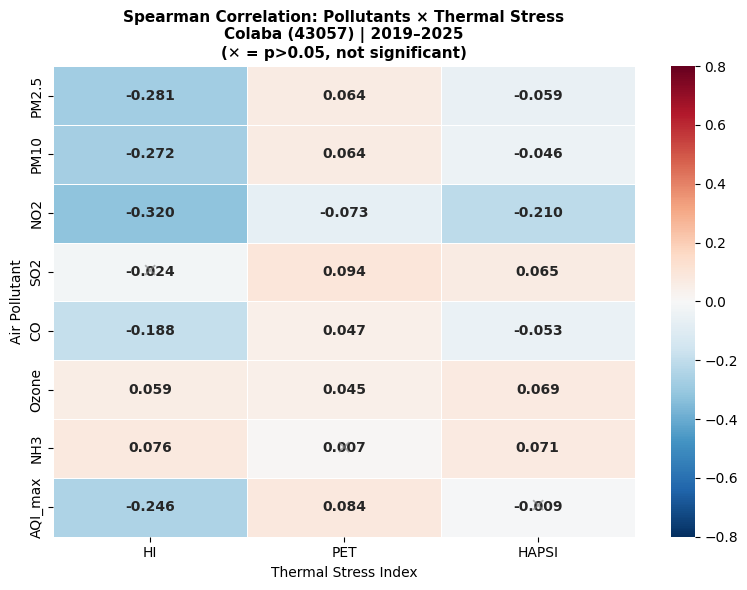

  ✅ Plot 1 saved: /content/drive/MyDrive/Major_project_imd/model_results_v2/43057_PET_corr_heatmap.png

  Spearman Correlation Matrix:
            HI    PET  HAPSI
PM2.5   -0.281  0.064 -0.059
PM10    -0.272  0.064 -0.046
NO2     -0.320 -0.073 -0.210
SO2     -0.024  0.094  0.065
CO      -0.188  0.047 -0.053
Ozone    0.059  0.045  0.069
NH3      0.076  0.007  0.071
AQI_max -0.246  0.084 -0.009


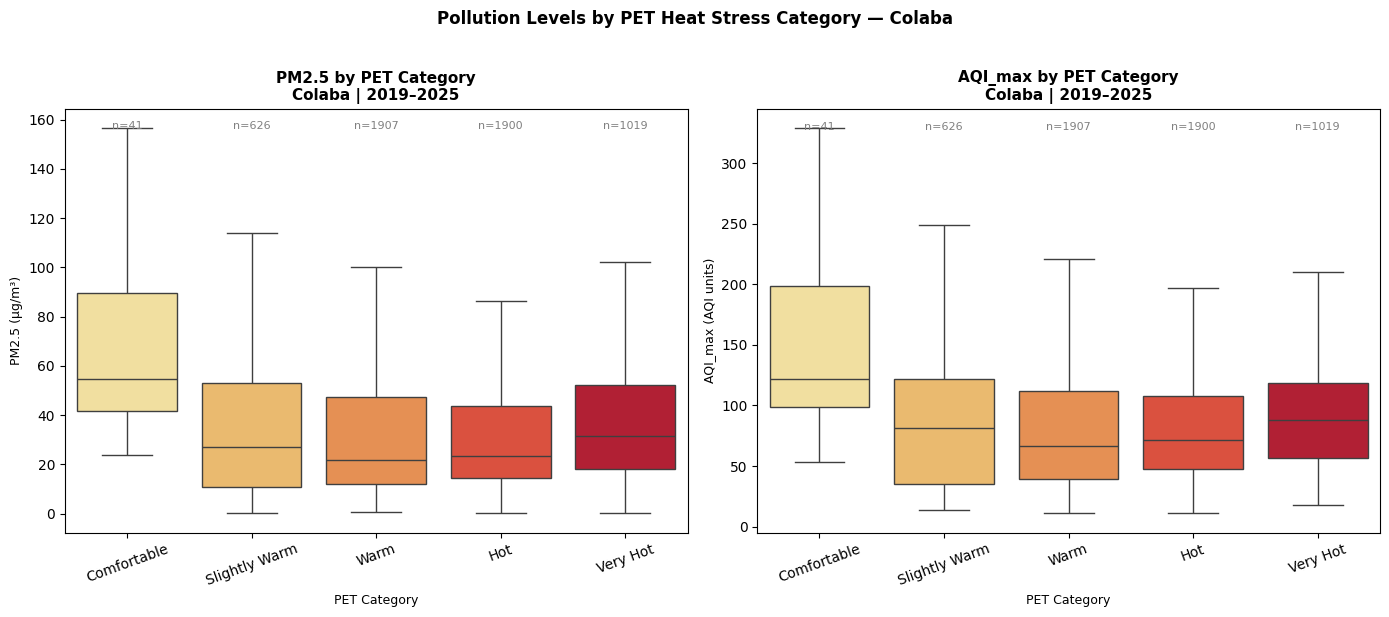

  ✅ Plot 2 saved: /content/drive/MyDrive/Major_project_imd/model_results_v2/43057_PET_boxplot_poll_by_cat.png


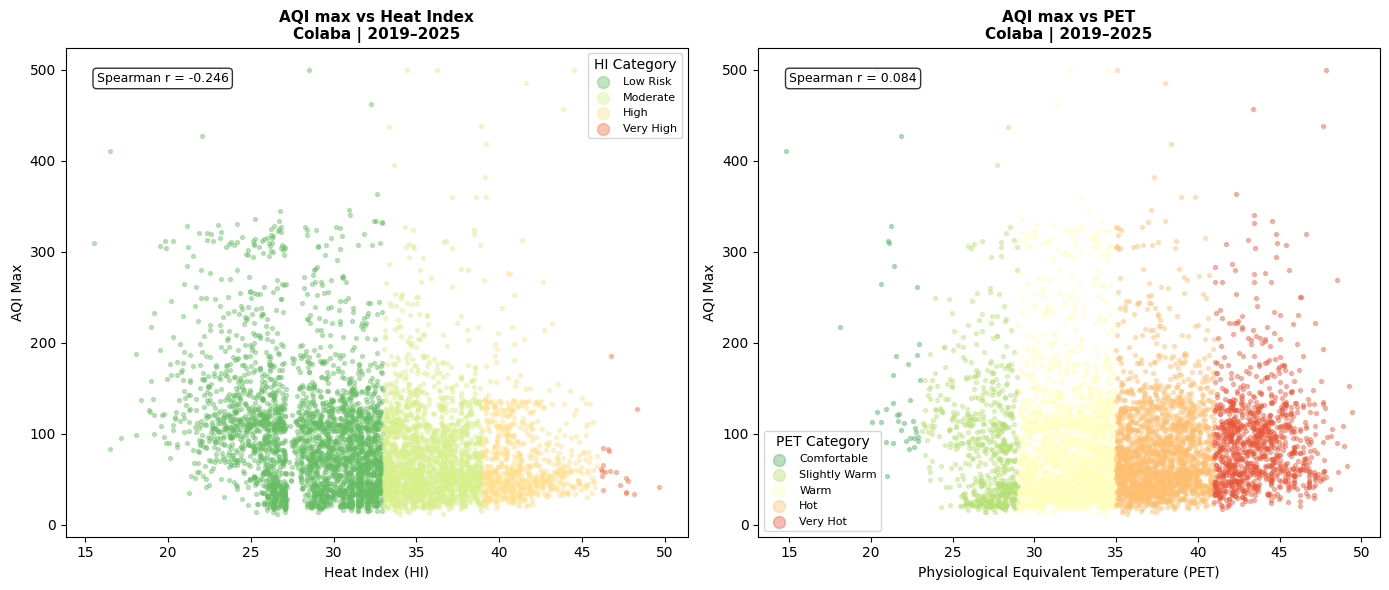

  ✅ Plot 3 saved: /content/drive/MyDrive/Major_project_imd/model_results_v2/43057_PET_scatter_AQI_vs_HI_PET.png


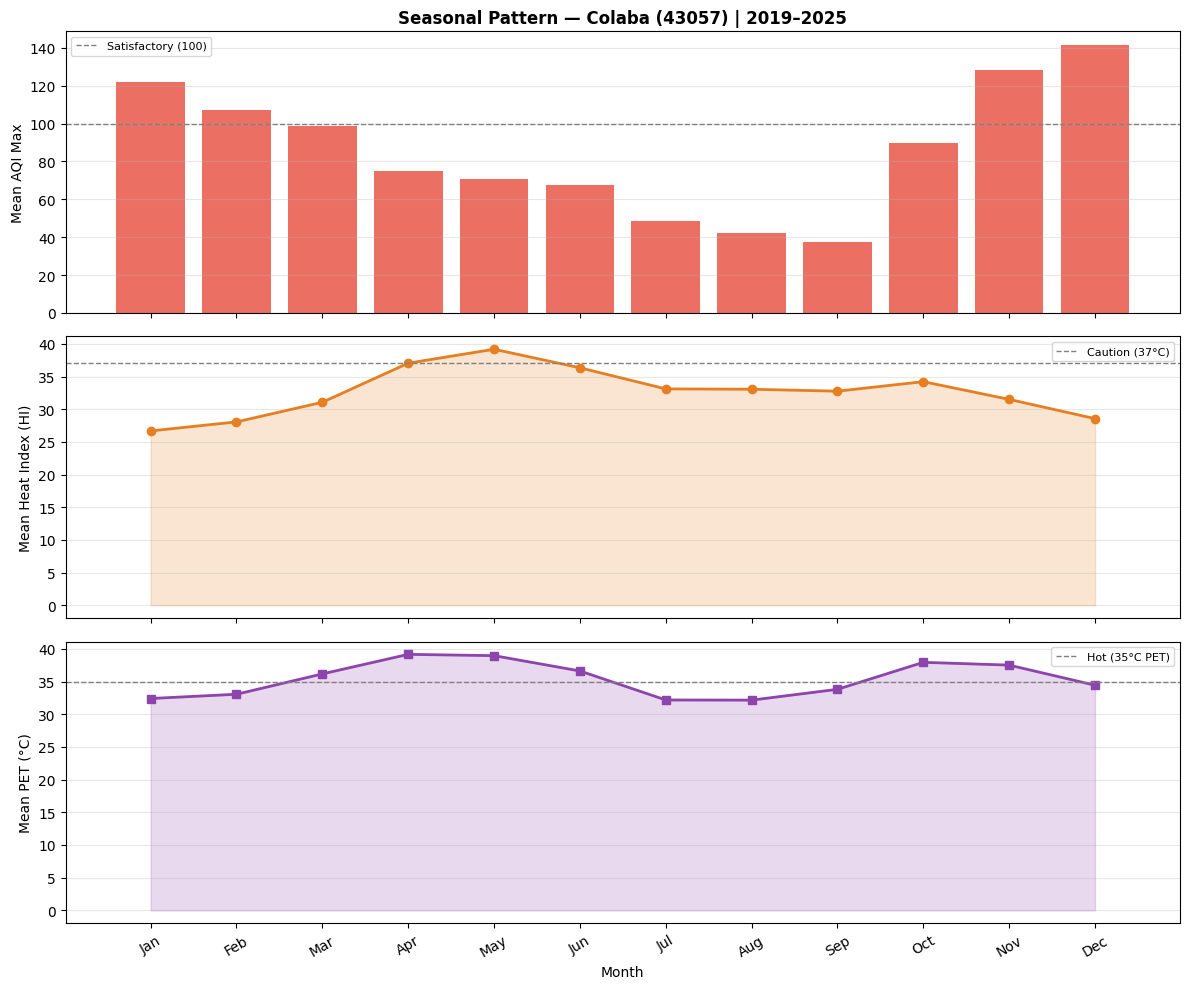

  ✅ Plot 4 saved: /content/drive/MyDrive/Major_project_imd/model_results_v2/43057_PET_seasonal_AQI_HI_PET.png


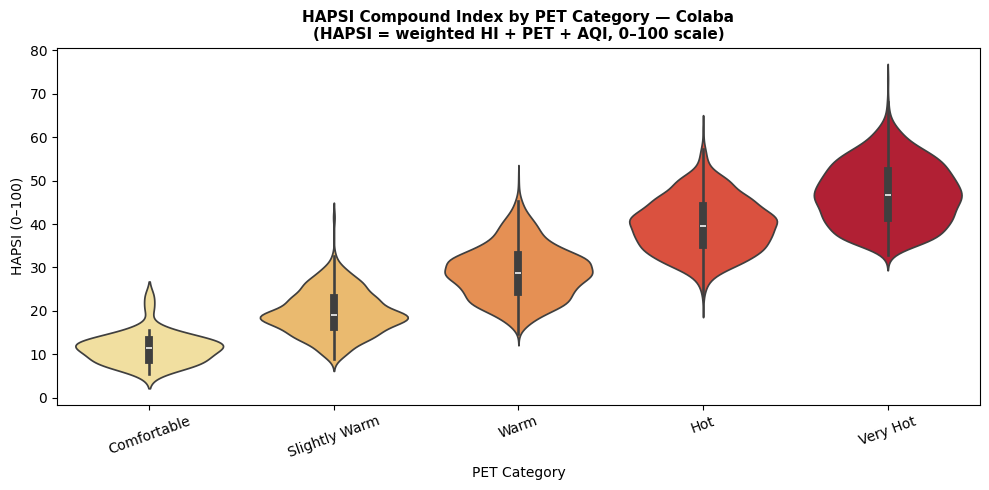

  ✅ Plot 5 saved: /content/drive/MyDrive/Major_project_imd/model_results_v2/43057_PET_HAPSI_violin.png

✅ All pollution correlation visualizations complete.
   Run with STATION_ID=43003 to get Santacruz plots for comparison.


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 3c — POLLUTION ↔ HI / PET CORRELATION VISUALIZATIONS               ║
# ║                                                                            ║
# ║  Four publication-quality plots:                                           ║
# ║  1. Correlation heatmap  (pollutants × thermal stress indices)             ║
# ║  2. Box plots of PM2.5 & AQI_max by HI / PET category                    ║
# ║  3. Scatter: AQI_max vs HI and PET (colour = category)                    ║
# ║  4. Monthly seasonal pattern of AQI_max vs HI/PET (Colaba only)           ║
# ║                                                                            ║
# ║  Note: For cross-station comparison (Colaba vs Santacruz), run once       ║
# ║  per station and compare the saved PNG files side-by-side.                ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '='*70)
print(f'  POLLUTION ↔ HI/PET CORRELATION ANALYSIS — {STATION} ({STATION_ID})')
print('='*70)

# ── Build analysis dataframe (2019-2025 rows only) ────────────────────────────
POLL_PLOT   = ['PM2.5','PM10','NO2','SO2','CO','Ozone','NH3','AQI_max']
poll_plot_avail = [c for c in POLL_PLOT if c in df_merge.columns]
analysis_cols   = ['YEAR','MN','HI','PET','HI_Category','PET_Category'] + poll_plot_avail + ['HAPSI']
analysis_cols   = [c for c in analysis_cols if c in df_merge.columns]

df_ana = df_merge[analysis_cols].dropna(subset=poll_plot_avail).copy()
print(f'  Analysis rows (2019-2025): {len(df_ana):,}')
print(f'  Pollutant columns: {poll_plot_avail}')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — Spearman Correlation Heatmap: Pollutants × {HI, PET, HAPSI}
# Spearman is used because pollutant distributions are non-normal (right-skewed)
# ─────────────────────────────────────────────────────────────────────────────
thermal_targets = [c for c in ['HI','PET','HAPSI'] if c in df_ana.columns]
corr_matrix     = pd.DataFrame(index=poll_plot_avail, columns=thermal_targets, dtype=float)
pval_matrix     = pd.DataFrame(index=poll_plot_avail, columns=thermal_targets, dtype=float)

for poll in poll_plot_avail:
    for target in thermal_targets:
        sub = df_ana[[poll, target]].dropna()
        if len(sub) > 30:
            r, p = spearmanr(sub[poll], sub[target])
            corr_matrix.loc[poll, target] = round(r, 3)
            pval_matrix.loc[poll, target] = p

fig, ax = plt.subplots(figsize=(8, 6))
mask_sig = pval_matrix > 0.05   # mask non-significant
sns.heatmap(
    corr_matrix.astype(float),
    annot=True, fmt='.3f', cmap='RdBu_r',
    vmin=-0.8, vmax=0.8, center=0,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 10, 'weight': 'bold'}
)
# Mark non-significant cells with ✕
for i, poll in enumerate(poll_plot_avail):
    for j, target in enumerate(thermal_targets):
        if pval_matrix.loc[poll, target] > 0.05:
            ax.text(j+0.5, i+0.5, '✕', ha='center', va='center',
                    fontsize=14, color='gray', alpha=0.6)

ax.set_title(f'Spearman Correlation: Pollutants × Thermal Stress\n{STATION} ({STATION_ID}) | 2019–2025\n(✕ = p>0.05, not significant)',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Thermal Stress Index', fontsize=10)
ax.set_ylabel('Air Pollutant',         fontsize=10)
plt.tight_layout()
fname_c = os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_corr_heatmap.png')
plt.savefig(fname_c, dpi=150, bbox_inches='tight')
plt.show(); plt.close()
print(f'  ✅ Plot 1 saved: {fname_c}')
print(f'\n  Spearman Correlation Matrix:')
print(corr_matrix.to_string())

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — Box plots: PM2.5 and AQI_max distribution by HI/PET category
# Shows whether higher heat stress coincides with higher pollution
# ─────────────────────────────────────────────────────────────────────────────
cat_col = TARGET_COL   # 'PET_Category' or 'HI_Category'

if cat_col in df_ana.columns:
    df_box = df_ana[[cat_col, 'PM2.5', 'AQI_max']].dropna()
    df_box[cat_col] = df_box[cat_col].astype(int)
    # Map integer categories to names
    cat_map = {i: CLASS_NAMES[i] for i in range(len(CLASS_NAMES))}
    df_box['Category'] = df_box[cat_col].map(cat_map)

    palette = sns.color_palette('YlOrRd', len(CLASS_NAMES))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, poll_col, unit in zip(axes,
                                   ['PM2.5',  'AQI_max'],
                                   ['µg/m³',  'AQI units']):
        order = CLASS_NAMES
        sns.boxplot(data=df_box, x='Category', y=poll_col, order=order,
                    palette=palette, ax=ax, showfliers=False)
        ax.set_title(f'{poll_col} by {TARGET} Category\n{STATION} | 2019–2025',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel(f'{TARGET} Category', fontsize=9)
        ax.set_ylabel(f'{poll_col} ({unit})', fontsize=9)
        ax.tick_params(axis='x', rotation=20)
        # Overlay sample counts
        for i, cat in enumerate(order):
            n = df_box[df_box['Category']==cat][poll_col].count()
            ax.text(i, ax.get_ylim()[1]*0.95, f'n={n}',
                    ha='center', fontsize=8, color='gray')

    plt.suptitle(f'Pollution Levels by {TARGET} Heat Stress Category — {STATION}',
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    fname_b = os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_boxplot_poll_by_cat.png')
    plt.savefig(fname_b, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f'  ✅ Plot 2 saved: {fname_b}')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — Scatter plots: AQI_max vs HI and PET
# Points colour-coded by the OTHER index's category for compound risk insight
# ─────────────────────────────────────────────────────────────────────────────
if 'HI' in df_ana.columns and 'PET' in df_ana.columns:
    df_sc_plot = df_ana[['HI','PET','AQI_max','HI_Category','PET_Category']].dropna().copy()
    df_sc_plot['HI_Category']  = df_sc_plot['HI_Category'].astype(int)
    df_sc_plot['PET_Category'] = df_sc_plot['PET_Category'].astype(int)

    if TARGET == 'PET':
        HI_NAMES  = ['Low Risk','Moderate','High','Very High']
        PET_NAMES = CLASS_NAMES
    else:
        HI_NAMES  = CLASS_NAMES
        PET_NAMES = ['Comfortable','Slightly Warm','Warm','Hot','Very Hot']

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: AQI vs HI, coloured by PET category
    n_hi_cats  = len(np.unique(df_sc_plot['HI_Category']))
    pal_hi = sns.color_palette('RdYlGn_r', n_hi_cats)
    for ci, (cat_val, grp) in enumerate(df_sc_plot.groupby('HI_Category')):
        lbl = HI_NAMES[cat_val] if cat_val < len(HI_NAMES) else str(cat_val)
        axes[0].scatter(grp['HI'], grp['AQI_max'], c=[pal_hi[ci]],
                        alpha=0.4, s=8, label=lbl)
    axes[0].set_xlabel('Heat Index (HI)', fontsize=10)
    axes[0].set_ylabel('AQI Max',         fontsize=10)
    axes[0].set_title(f'AQI max vs Heat Index\n{STATION} | 2019–2025', fontsize=11, fontweight='bold')
    axes[0].legend(title='HI Category', fontsize=8, markerscale=3)

    # Add Spearman r annotation
    r_hi, _ = spearmanr(df_sc_plot['HI'], df_sc_plot['AQI_max'])
    axes[0].annotate(f'Spearman r = {r_hi:.3f}', xy=(0.05, 0.93),
                     xycoords='axes fraction', fontsize=9,
                     bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    # Right: AQI vs PET
    n_pet_cats = len(np.unique(df_sc_plot['PET_Category']))
    pal_pet = sns.color_palette('RdYlGn_r', n_pet_cats)
    for ci, (cat_val, grp) in enumerate(df_sc_plot.groupby('PET_Category')):
        lbl = PET_NAMES[cat_val] if cat_val < len(PET_NAMES) else str(cat_val)
        axes[1].scatter(grp['PET'], grp['AQI_max'], c=[pal_pet[ci]],
                        alpha=0.4, s=8, label=lbl)
    axes[1].set_xlabel('Physiological Equivalent Temperature (PET)', fontsize=10)
    axes[1].set_ylabel('AQI Max', fontsize=10)
    axes[1].set_title(f'AQI max vs PET\n{STATION} | 2019–2025', fontsize=11, fontweight='bold')
    axes[1].legend(title='PET Category', fontsize=8, markerscale=3)
    r_pet, _ = spearmanr(df_sc_plot['PET'], df_sc_plot['AQI_max'])
    axes[1].annotate(f'Spearman r = {r_pet:.3f}', xy=(0.05, 0.93),
                     xycoords='axes fraction', fontsize=9,
                     bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    plt.tight_layout()
    fname_s = os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_scatter_AQI_vs_HI_PET.png')
    plt.savefig(fname_s, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f'  ✅ Plot 3 saved: {fname_s}')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — Seasonal Pattern: monthly mean AQI_max, HI, PET (2019-2025)
# Reveals winter pollution spikes vs summer heat stress peaks
# ─────────────────────────────────────────────────────────────────────────────
if 'MN' in df_ana.columns:
    monthly = df_ana.groupby('MN')[['AQI_max','HI','PET']].mean()
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    monthly.index = [month_names[i-1] for i in monthly.index]

    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    axes[0].bar(monthly.index, monthly['AQI_max'], color='#e74c3c', alpha=0.8)
    axes[0].set_ylabel('Mean AQI Max', fontsize=10)
    axes[0].set_title(f'Seasonal Pattern — {STATION} ({STATION_ID}) | 2019–2025', fontsize=12, fontweight='bold')
    axes[0].axhline(100, color='gray', linestyle='--', linewidth=1, label='Satisfactory (100)')
    axes[0].legend(fontsize=8)

    axes[1].plot(monthly.index, monthly['HI'], 'o-', color='#e67e22', linewidth=2, markersize=6)
    axes[1].fill_between(monthly.index, monthly['HI'], alpha=0.2, color='#e67e22')
    axes[1].set_ylabel('Mean Heat Index (HI)', fontsize=10)
    axes[1].axhline(37, color='gray', linestyle='--', linewidth=1, label='Caution (37°C)')
    axes[1].legend(fontsize=8)

    axes[2].plot(monthly.index, monthly['PET'], 's-', color='#8e44ad', linewidth=2, markersize=6)
    axes[2].fill_between(monthly.index, monthly['PET'], alpha=0.2, color='#8e44ad')
    axes[2].set_ylabel('Mean PET (°C)', fontsize=10)
    axes[2].set_xlabel('Month', fontsize=10)
    axes[2].axhline(35, color='gray', linestyle='--', linewidth=1, label='Hot (35°C PET)')
    axes[2].legend(fontsize=8)

    for ax in axes:
        ax.tick_params(axis='x', rotation=30)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    fname_m = os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_seasonal_AQI_HI_PET.png')
    plt.savefig(fname_m, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f'  ✅ Plot 4 saved: {fname_m}')

# ─────────────────────────────────────────────────────────────────────────────
# PLOT 5 — HAPSI composite index by HI/PET category (compound risk)
# ─────────────────────────────────────────────────────────────────────────────
if 'HAPSI' in df_ana.columns and cat_col in df_ana.columns:
    df_hap = df_ana[[cat_col,'HAPSI']].dropna()
    df_hap[cat_col] = df_hap[cat_col].astype(int)
    df_hap['Category'] = df_hap[cat_col].map(cat_map)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.violinplot(data=df_hap, x='Category', y='HAPSI', order=CLASS_NAMES,
                   palette='YlOrRd', ax=ax, inner='box')
    ax.set_title(f'HAPSI Compound Index by {TARGET} Category — {STATION}\n'
                 f'(HAPSI = weighted HI + PET + AQI, 0–100 scale)',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{TARGET} Category', fontsize=10)
    ax.set_ylabel('HAPSI (0–100)', fontsize=10)
    ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    fname_h = os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_HAPSI_violin.png')
    plt.savefig(fname_h, dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    print(f'  ✅ Plot 5 saved: {fname_h}')

# Save correlation table
corr_matrix.to_csv(os.path.join(OUTPUT_DIR,
    f'{STATION_ID}_{TARGET}_pollutant_corr_table.csv'))
print(f'\n✅ All pollution correlation visualizations complete.')
print(f'   Run with STATION_ID=43003 to get Santacruz plots for comparison.')

In [10]:
# CELL 4 — SMOTE-ENN Balancing — Model 1 (thermal only)
print('Applying SMOTE-ENN on Model 1 training data...')
smote_enn = SMOTEENN(smote=SMOTE(k_neighbors=3, random_state=SEED), random_state=SEED, n_jobs=-1)
X_phys = train_raw[PHYSICAL].values
X_phys_bal, y_train_bal = smote_enn.fit_resample(X_phys, y_train_raw)

nn_fit = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(X_phys)
_, idx = nn_fit.kneighbors(X_phys_bal)
X_temp_bal  = train_raw[TEMPORAL].values[idx.flatten()]
X_train_bal = np.hstack([X_phys_bal, X_temp_bal])
feat_order  = PHYSICAL + TEMPORAL
reorder_idx = [feat_order.index(f) for f in FEATURES]
X_train_bal = X_train_bal[:, reorder_idx]

print(f'Balanced train : {Counter(y_train_bal)}')
print(f'Shape          : {X_train_bal.shape}')

Applying SMOTE-ENN on Model 1 training data...
Balanced train : Counter({np.int64(0): 17993, np.int64(4): 16487, np.int64(1): 14910, np.int64(3): 11809, np.int64(2): 11670})
Shape          : (72869, 10)


In [11]:
# CELL 4b — SMOTE-ENN Balancing — Model 2 (thermal + pollution)
print('Applying SMOTE-ENN on Model 2 training data...')
PHYS_IDX_P = [FEATURES_POLL.index(f) for f in PHYSICAL_POLL if f in FEATURES_POLL]
TEMP_IDX_P = [FEATURES_POLL.index(f) for f in TEMPORAL      if f in FEATURES_POLL]
k_nb = max(1, min(3, min(Counter(y_tr_p_raw).values()) - 1))
try:
    se_p = SMOTEENN(smote=SMOTE(k_neighbors=k_nb, random_state=SEED), random_state=SEED, n_jobs=-1)
    X_phys_p_bal, y_tr_p_bal = se_p.fit_resample(X_tr_p_raw[:, PHYS_IDX_P], y_tr_p_raw)
    nn_p = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(X_tr_p_raw[:, PHYS_IDX_P])
    _, idx_p = nn_p.kneighbors(X_phys_p_bal)
    X_temp_p_bal = X_tr_p_raw[idx_p.flatten()][:, TEMP_IDX_P]
    X_tr_p_bal = np.zeros((len(X_phys_p_bal), len(FEATURES_POLL)))
    X_tr_p_bal[:, PHYS_IDX_P] = X_phys_p_bal
    X_tr_p_bal[:, TEMP_IDX_P] = X_temp_p_bal
    print(f'Balanced Model 2 train: {Counter(y_tr_p_bal)}')
except Exception as e:
    print(f'SMOTE-ENN failed ({e}) — using raw data for Model 2.')
    X_tr_p_bal = X_tr_p_raw.copy()
    y_tr_p_bal = y_tr_p_raw.copy()

Applying SMOTE-ENN on Model 2 training data...
Balanced Model 2 train: Counter({np.int64(0): 822, np.int64(1): 722, np.int64(4): 625, np.int64(3): 212, np.int64(2): 185})


In [12]:
# CELL 5 — Scaling + Class Weights — both models
scaler_bal = StandardScaler().fit(X_train_bal)
X_tr_bal   = scaler_bal.transform(X_train_bal)
X_v_bal    = scaler_bal.transform(X_val)
X_te_bal   = scaler_bal.transform(X_test)

scaler_imb = StandardScaler().fit(X_train_raw)
X_tr_imb   = scaler_imb.transform(X_train_raw)
X_v_imb    = scaler_imb.transform(X_val)
X_te_imb   = scaler_imb.transform(X_test)

cw_arr  = compute_class_weight('balanced', classes=ALL_CLASSES, y=y_train_raw)
CW_DICT = dict(zip(ALL_CLASSES, cw_arr))

scaler_p_bal = StandardScaler().fit(X_tr_p_bal)
X_tr_pb      = scaler_p_bal.transform(X_tr_p_bal)
X_v_pb       = scaler_p_bal.transform(X_v_p)
X_te_pb      = scaler_p_bal.transform(X_te_p)

scaler_p_imb = StandardScaler().fit(X_tr_p_raw)
X_tr_pi      = scaler_p_imb.transform(X_tr_p_raw)
X_v_pi       = scaler_p_imb.transform(X_v_p)
X_te_pi      = scaler_p_imb.transform(X_te_p)

cw_arr_p  = compute_class_weight('balanced', classes=ALL_CLASSES_P, y=y_tr_p_raw)
CW_DICT_P = dict(zip(ALL_CLASSES_P, cw_arr_p))

y_tr_bal_idx  = np.searchsorted(ALL_CLASSES, y_train_bal)
y_tr_imb_idx  = np.searchsorted(ALL_CLASSES, y_train_raw)
y_v_idx       = np.searchsorted(ALL_CLASSES, y_val)
y_te_idx      = np.searchsorted(ALL_CLASSES, y_test)

c2i_p          = {c:i for i,c in enumerate(ALL_CLASSES_P)}
y_tr_p_bal_idx = np.array([c2i_p[c] for c in y_tr_p_bal])
y_tr_p_imb_idx = np.array([c2i_p[c] for c in y_tr_p_raw])
y_v_p_idx      = np.array([c2i_p[c] for c in y_v_p])
y_te_p_idx     = np.array([c2i_p[c] for c in y_te_p])

print(f'Model 1 class weights: {CW_DICT}')
print(f'Model 2 class weights: {CW_DICT_P}')
print('✅ All scalers ready.')

Model 1 class weights: {np.int64(0): np.float64(5.363949635520212), np.int64(1): np.float64(0.9327264346623646), np.int64(2): np.float64(0.4364861949956859), np.int64(3): np.float64(0.7789625637570975), np.int64(4): np.float64(6.000148257968866)}
Model 2 class weights: {np.int64(0): np.float64(137.33333333333334), np.int64(1): np.float64(1.5547169811320756), np.int64(2): np.float64(0.5012165450121655), np.int64(3): np.float64(0.6023391812865497), np.int64(4): np.float64(1.4405594405594406)}
✅ All scalers ready.


In [13]:
# CELL 6 — Evaluation + Plotting Utilities
ALL_RESULTS = []

def evaluate_model(name, y_true, y_pred, y_proba, split, training_type, train_time=0):
    m = {
        'Model': name, 'Split': split, 'Training_Type': training_type,
        'Accuracy'    : round(accuracy_score(y_true, y_pred), 4),
        'F1_macro'    : round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'F1_weighted' : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Precision'   : round(precision_score(y_true, y_pred, average='macro', zero_division=0), 4),
        'Recall'      : round(recall_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'Kappa'       : round(cohen_kappa_score(y_true, y_pred), 4),
        'Train_Time_s': round(train_time, 1),
    }
    if y_proba is not None:
        try:
            m['ROC_AUC'] = round(roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted'), 4)
        except: m['ROC_AUC'] = np.nan
    ALL_RESULTS.append(m)
    return m

def full_evaluate(name, y_tr, y_tr_pred, y_v, y_v_pred, y_v_proba,
                  y_te, y_te_pred, y_te_proba, tt, training_type, class_names=None):
    cn = class_names or CLASS_NAMES
    evaluate_model(name, y_tr, y_tr_pred, None,      'Train',      training_type, tt)
    evaluate_model(name, y_v,  y_v_pred,  y_v_proba, 'Validation', training_type, tt)
    m = evaluate_model(name, y_te, y_te_pred, y_te_proba, 'Test',  training_type, tt)
    print(f'\n{"="*70}')
    print(f'  {name} ({training_type}) — Test')
    print(f'{"="*70}')
    print(f'  Acc={m["Accuracy"]:.4f}  F1={m["F1_macro"]:.4f}  Kappa={m["Kappa"]:.4f}  ROC={m.get("ROC_AUC","N/A")}')
    print(classification_report(y_te, y_te_pred, target_names=cn, zero_division=0))
    return m

def plot_confusion(y_true, y_pred, title, class_names=None):
    cn = class_names or CLASS_NAMES
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cn, yticklabels=cn, ax=ax)
    ax.set_title(f'CM — {title}', fontsize=11); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_cm_{title}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

print('✅ Utility functions ready.')

✅ Utility functions ready.


In [14]:
# CELL 7 — DL + Sklearn Training Utilities
def get_dl_callbacks(name, patience=20):
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True, verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-7, verbose=0),
    ]

def plot_dl_history(hist, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist.history['loss'], label='Train'); axes[0].plot(hist.history['val_loss'], label='Val')
    axes[0].set_title(f'{title} — Loss'); axes[0].legend()
    axes[1].plot(hist.history['accuracy'], label='Train'); axes[1].plot(hist.history['val_accuracy'], label='Val')
    axes[1].set_title(f'{title} — Accuracy'); axes[1].legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_hist_{title}.png'), dpi=150, bbox_inches='tight')
    plt.show(); plt.close()

def train_dl(model, name, X_tr, y_tr, X_v, y_v, X_te, y_te,
             y_te_orig, training_type, use_cw=True, cw=None, cls_arr=None, class_names=None):
    cw_use  = cw      if cw      is not None else CW_DICT
    cls_use = cls_arr if cls_arr is not None else np.array(ALL_CLASSES)
    cn_use  = class_names or CLASS_NAMES
    print(f'\n{"─"*50}\nTraining {name} ({training_type})...')
    t0 = time.time()
    hist = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                     epochs=EPOCHS, batch_size=BATCH_SIZE,
                     class_weight=cw_use if use_cw else None,
                     callbacks=get_dl_callbacks(name), verbose=0)
    tt = time.time() - t0
    plot_dl_history(hist, f'{name}_{training_type}')
    y_tr_pred=model.predict(X_tr,verbose=0).argmax(axis=1)
    y_v_pred=model.predict(X_v,verbose=0).argmax(axis=1)
    y_te_proba=model.predict(X_te,verbose=0)
    y_te_pred=y_te_proba.argmax(axis=1)
    y_v_proba=model.predict(X_v,verbose=0)
    full_evaluate(name, cls_use[y_tr], cls_use[y_tr_pred], cls_use[y_v], cls_use[y_v_pred], y_v_proba,
                  y_te_orig, cls_use[y_te_pred], y_te_proba, tt, training_type, class_names=cn_use)
    plot_confusion(y_te_orig, cls_use[y_te_pred], f'{name}_{training_type}', class_names=cn_use)
    try: model.save(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_{name}_{training_type}.keras'))
    except: pass
    gc.collect()
    return model, hist

def train_sklearn(model, name, X_tr, y_tr, X_v, y_v, X_te, y_te, training_type, class_names=None):
    print(f'\n{"─"*50}\nTraining {name} ({training_type})...')
    t0 = time.time(); model.fit(X_tr, y_tr); tt = time.time()-t0
    y_tr_pred=model.predict(X_tr); y_v_pred=model.predict(X_v); y_te_pred=model.predict(X_te)
    y_v_proba=model.predict_proba(X_v) if hasattr(model,'predict_proba') else None
    y_te_proba=model.predict_proba(X_te) if hasattr(model,'predict_proba') else None
    full_evaluate(name,y_tr,y_tr_pred,y_v,y_v_pred,y_v_proba,y_te,y_te_pred,y_te_proba,tt,training_type,class_names=class_names)
    plot_confusion(y_te,y_te_pred,f'{name}_{training_type}',class_names=class_names)
    return model

print('✅ Training utilities ready.')

✅ Training utilities ready.



──────────────────────────────────────────────────
Training KNN (Balanced)...

  KNN (Balanced) — Test
  Acc=0.7645  F1=0.7661  Kappa=0.6740  ROC=0.8804
               precision    recall  f1-score   support

  Comfortable       0.67      0.86      0.75        78
Slightly Warm       0.72      0.88      0.79      1128
         Warm       0.80      0.77      0.79      3444
          Hot       0.79      0.66      0.72      3346
     Very Hot       0.70      0.88      0.78      1579

     accuracy                           0.76      9575
    macro avg       0.74      0.81      0.77      9575
 weighted avg       0.77      0.76      0.76      9575



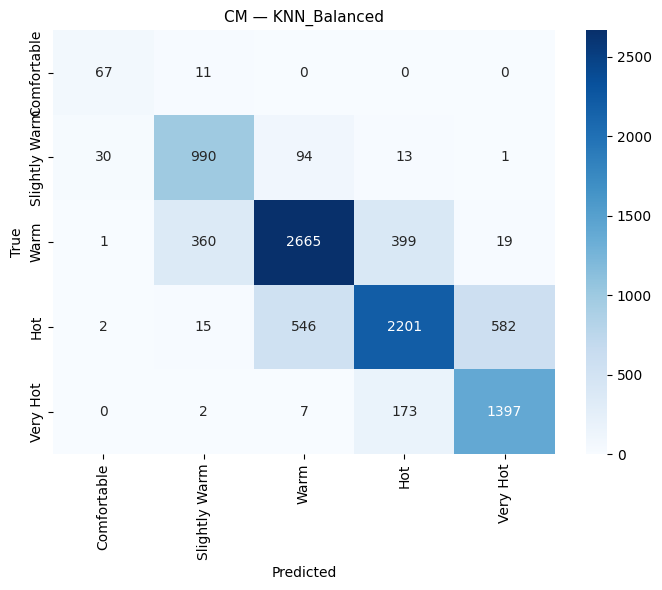


──────────────────────────────────────────────────
Training KNN (Imbalanced)...

  KNN (Imbalanced) — Test
  Acc=0.8096  F1=0.8170  Kappa=0.7285  ROC=0.9291
               precision    recall  f1-score   support

  Comfortable       0.95      0.73      0.83        78
Slightly Warm       0.86      0.85      0.86      1128
         Warm       0.80      0.86      0.83      3444
          Hot       0.77      0.78      0.78      3346
     Very Hot       0.87      0.73      0.79      1579

     accuracy                           0.81      9575
    macro avg       0.85      0.79      0.82      9575
 weighted avg       0.81      0.81      0.81      9575



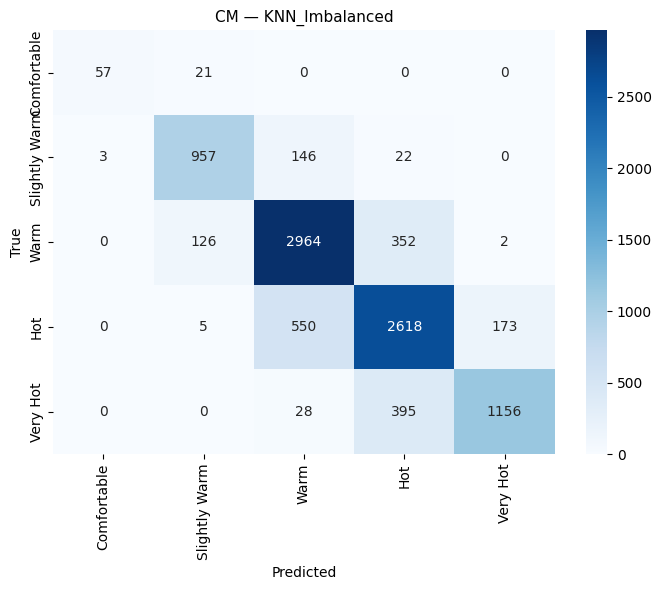


──────────────────────────────────────────────────
Training SVC (Balanced)...

  SVC (Balanced) — Test
  Acc=0.8021  F1=0.8048  Kappa=0.7266  ROC=0.9518
               precision    recall  f1-score   support

  Comfortable       0.76      0.83      0.80        78
Slightly Warm       0.79      0.89      0.84      1128
         Warm       0.85      0.81      0.83      3444
          Hot       0.84      0.68      0.75      3346
     Very Hot       0.69      0.97      0.80      1579

     accuracy                           0.80      9575
    macro avg       0.79      0.84      0.80      9575
 weighted avg       0.81      0.80      0.80      9575



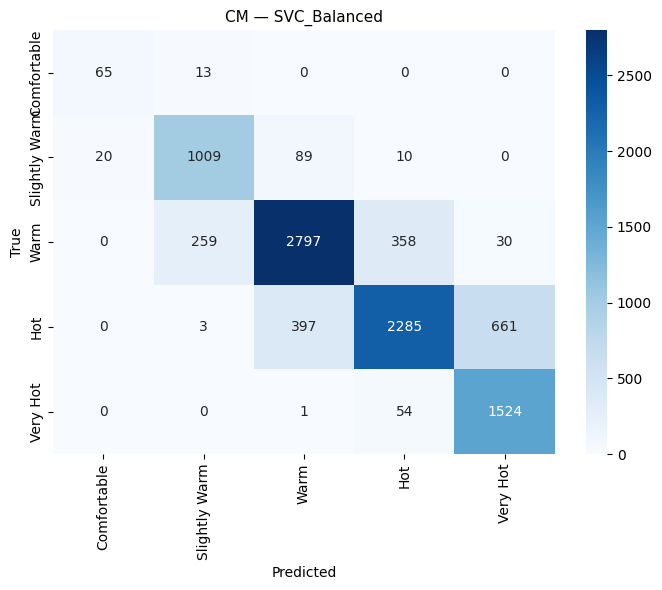


──────────────────────────────────────────────────
Training SVC (Imbalanced)...

  SVC (Imbalanced) — Test
  Acc=0.8277  F1=0.8209  Kappa=0.7604  ROC=0.9636
               precision    recall  f1-score   support

  Comfortable       0.74      0.82      0.78        78
Slightly Warm       0.81      0.88      0.84      1128
         Warm       0.89      0.81      0.85      3444
          Hot       0.83      0.76      0.80      3346
     Very Hot       0.74      0.95      0.83      1579

     accuracy                           0.83      9575
    macro avg       0.80      0.85      0.82      9575
 weighted avg       0.83      0.83      0.83      9575



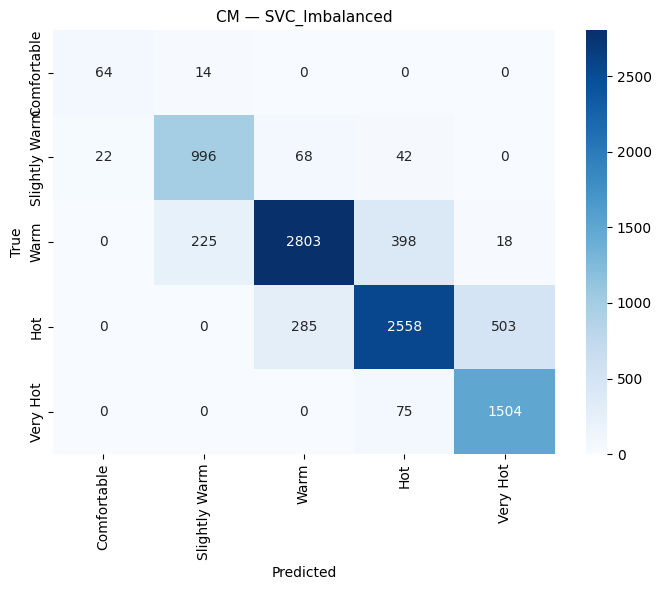


──────────────────────────────────────────────────
Training MLP-sklearn (Balanced)...

  MLP-sklearn (Balanced) — Test
  Acc=0.7916  F1=0.8000  Kappa=0.7112  ROC=0.9487
               precision    recall  f1-score   support

  Comfortable       0.81      0.81      0.81        78
Slightly Warm       0.82      0.85      0.84      1128
         Warm       0.85      0.80      0.82      3444
          Hot       0.81      0.68      0.74      3346
     Very Hot       0.68      0.96      0.79      1579

     accuracy                           0.79      9575
    macro avg       0.79      0.82      0.80      9575
 weighted avg       0.80      0.79      0.79      9575



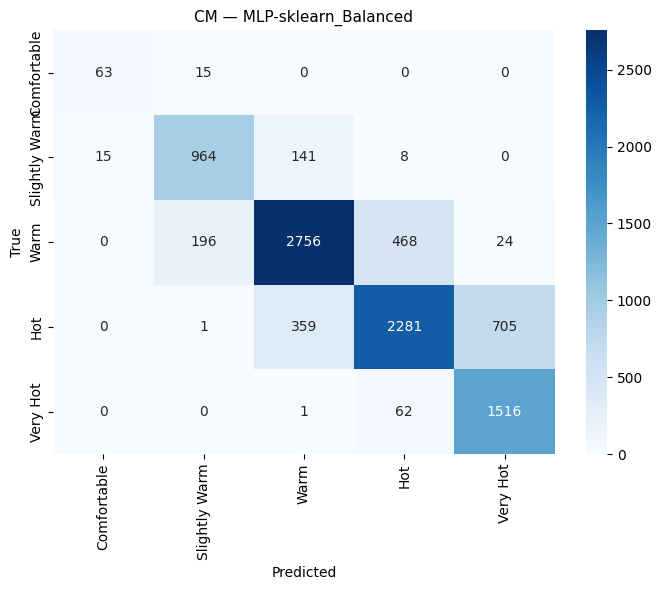


──────────────────────────────────────────────────
Training MLP-sklearn (Imbalanced)...

  MLP-sklearn (Imbalanced) — Test
  Acc=0.8369  F1=0.8410  Kappa=0.7670  ROC=0.962
               precision    recall  f1-score   support

  Comfortable       0.97      0.77      0.86        78
Slightly Warm       0.92      0.83      0.87      1128
         Warm       0.85      0.89      0.87      3444
          Hot       0.79      0.83      0.81      3346
     Very Hot       0.86      0.74      0.80      1579

     accuracy                           0.84      9575
    macro avg       0.88      0.81      0.84      9575
 weighted avg       0.84      0.84      0.84      9575



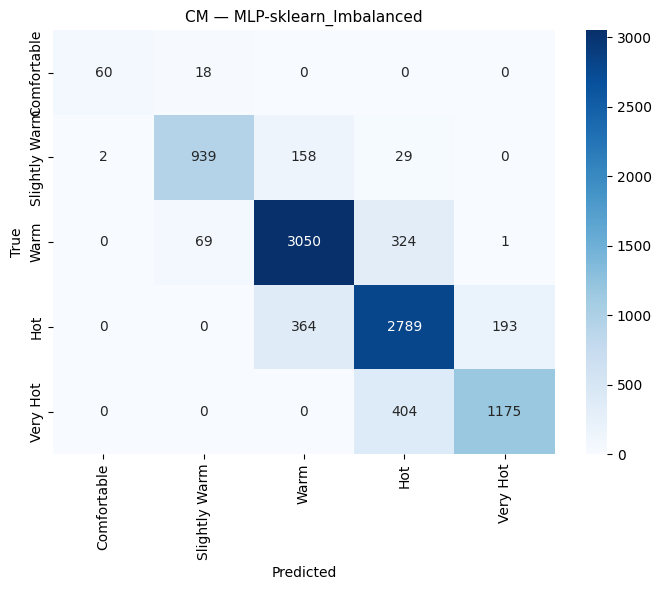


──────────────────────────────────────────────────
Training NaiveBayes (Balanced)...

  NaiveBayes (Balanced) — Test
  Acc=0.5040  F1=0.4496  Kappa=0.3234  ROC=0.7563
               precision    recall  f1-score   support

  Comfortable       0.15      0.92      0.25        78
Slightly Warm       0.31      0.45      0.37      1128
         Warm       0.53      0.59      0.56      3444
          Hot       0.63      0.39      0.48      3346
     Very Hot       0.60      0.58      0.59      1579

     accuracy                           0.50      9575
    macro avg       0.44      0.59      0.45      9575
 weighted avg       0.55      0.50      0.51      9575



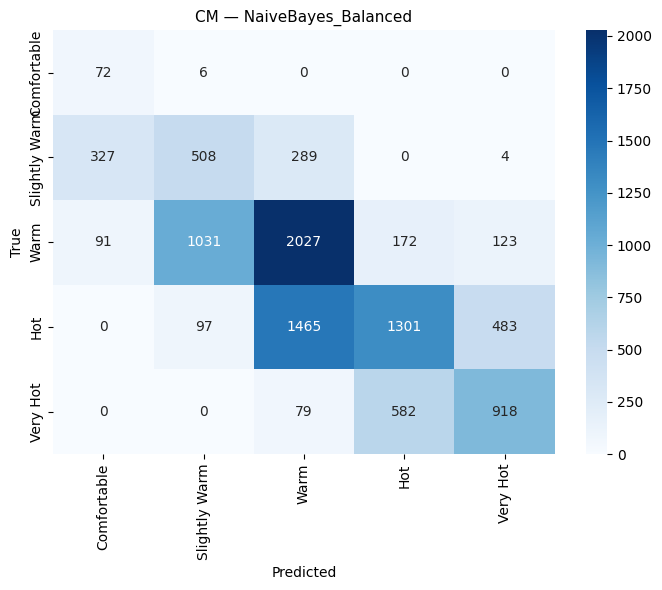


──────────────────────────────────────────────────
Training NaiveBayes (Imbalanced)...

  NaiveBayes (Imbalanced) — Test
  Acc=0.4079  F1=0.3595  Kappa=0.2377  ROC=0.7653
               precision    recall  f1-score   support

  Comfortable       0.18      0.86      0.30        78
Slightly Warm       0.38      0.40      0.39      1128
         Warm       0.55      0.50      0.52      3444
          Hot       0.58      0.06      0.10      3346
     Very Hot       0.32      0.93      0.48      1579

     accuracy                           0.41      9575
    macro avg       0.40      0.55      0.36      9575
 weighted avg       0.50      0.41      0.35      9575



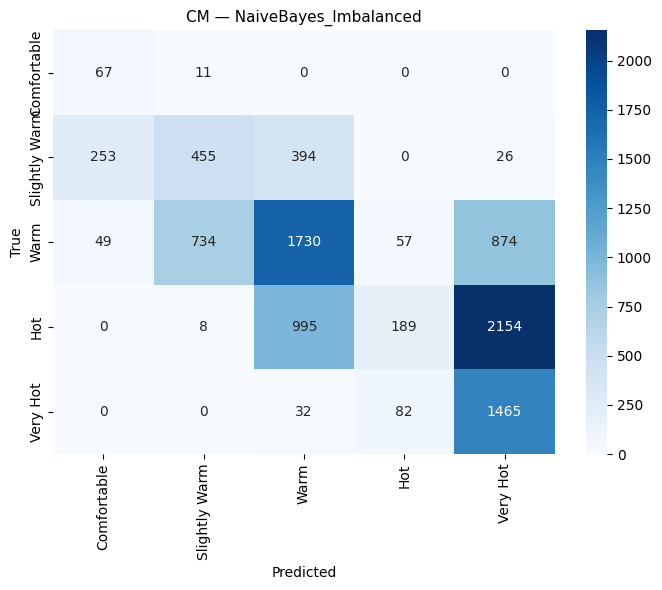


──────────────────────────────────────────────────
Training RandomForest (Balanced)...

  RandomForest (Balanced) — Test
  Acc=0.7896  F1=0.8034  Kappa=0.7061  ROC=0.9391
               precision    recall  f1-score   support

  Comfortable       0.82      0.85      0.84        78
Slightly Warm       0.77      0.88      0.82      1128
         Warm       0.81      0.81      0.81      3444
          Hot       0.80      0.70      0.75      3346
     Very Hot       0.75      0.87      0.80      1579

     accuracy                           0.79      9575
    macro avg       0.79      0.82      0.80      9575
 weighted avg       0.79      0.79      0.79      9575



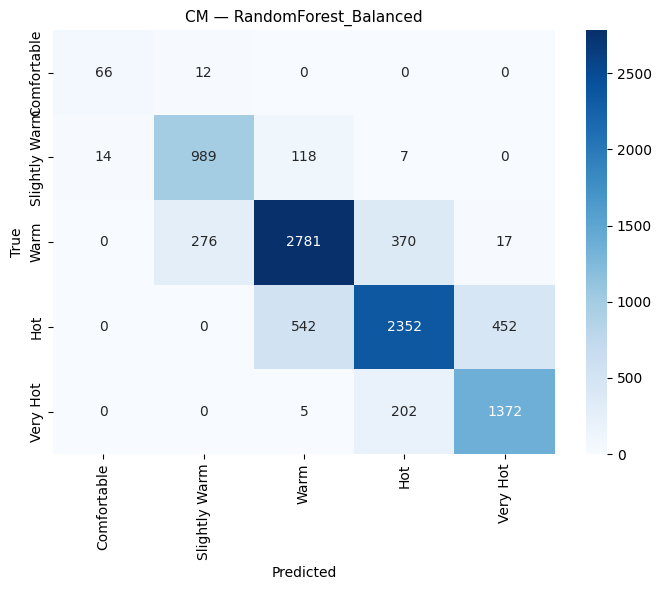


──────────────────────────────────────────────────
Training RandomForest (Imbalanced)...

  RandomForest (Imbalanced) — Test
  Acc=0.8155  F1=0.8229  Kappa=0.7372  ROC=0.9552
               precision    recall  f1-score   support

  Comfortable       0.92      0.76      0.83        78
Slightly Warm       0.87      0.86      0.87      1128
         Warm       0.84      0.85      0.84      3444
          Hot       0.76      0.81      0.78      3346
     Very Hot       0.85      0.74      0.79      1579

     accuracy                           0.82      9575
    macro avg       0.85      0.80      0.82      9575
 weighted avg       0.82      0.82      0.82      9575



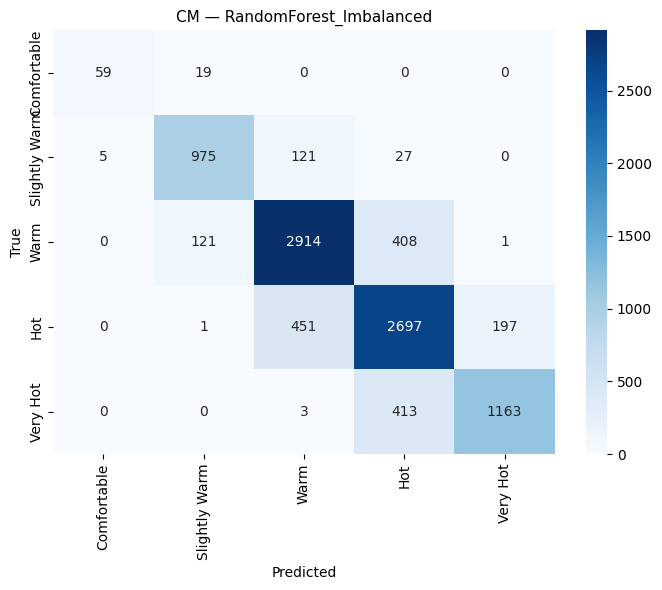


──────────────────────────────────────────────────
Training AdaBoost (Balanced)...

  AdaBoost (Balanced) — Test
  Acc=0.6354  F1=0.4260  Kappa=0.4636  ROC=0.8103
               precision    recall  f1-score   support

  Comfortable       0.03      0.12      0.04        78
Slightly Warm       0.76      0.58      0.66      1128
         Warm       0.72      0.88      0.79      3444
          Hot       0.58      0.71      0.64      3346
     Very Hot       0.00      0.00      0.00      1579

     accuracy                           0.64      9575
    macro avg       0.42      0.46      0.43      9575
 weighted avg       0.55      0.64      0.59      9575



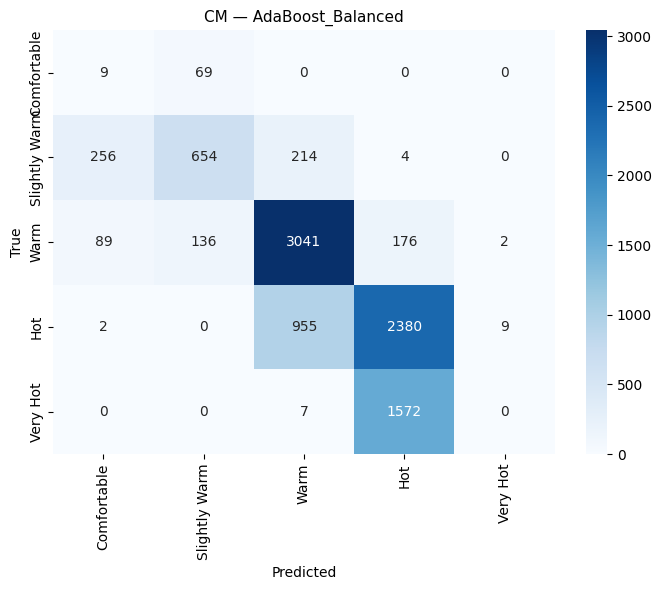


──────────────────────────────────────────────────
Training AdaBoost (Imbalanced)...

  AdaBoost (Imbalanced) — Test
  Acc=0.6342  F1=0.4192  Kappa=0.4570  ROC=0.8054
               precision    recall  f1-score   support

  Comfortable       0.03      0.12      0.05        78
Slightly Warm       0.82      0.49      0.61      1128
         Warm       0.72      0.84      0.78      3444
          Hot       0.57      0.78      0.66      3346
     Very Hot       0.00      0.00      0.00      1579

     accuracy                           0.63      9575
    macro avg       0.43      0.45      0.42      9575
 weighted avg       0.56      0.63      0.58      9575



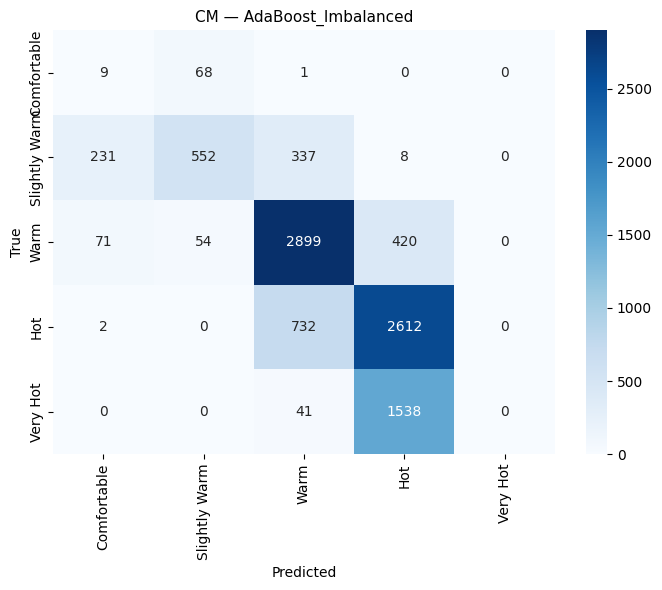


──────────────────────────────────────────────────
Training LDA (Balanced)...

  LDA (Balanced) — Test
  Acc=0.7066  F1=0.6425  Kappa=0.5940  ROC=0.9054
               precision    recall  f1-score   support

  Comfortable       0.25      0.85      0.39        78
Slightly Warm       0.54      0.66      0.60      1128
         Warm       0.69      0.76      0.72      3444
          Hot       0.82      0.60      0.69      3346
     Very Hot       0.78      0.86      0.82      1579

     accuracy                           0.71      9575
    macro avg       0.62      0.74      0.64      9575
 weighted avg       0.73      0.71      0.71      9575



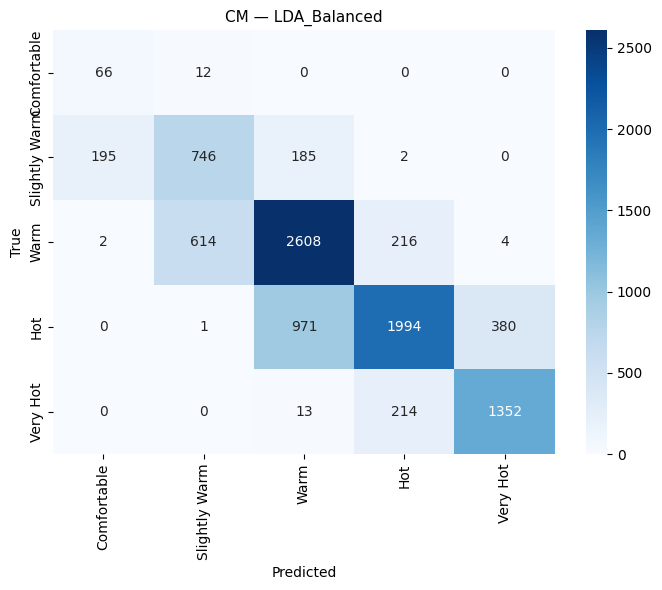


──────────────────────────────────────────────────
Training LDA (Imbalanced)...

  LDA (Imbalanced) — Test
  Acc=0.6772  F1=0.6016  Kappa=0.5334  ROC=0.8956
               precision    recall  f1-score   support

  Comfortable       0.31      0.59      0.41        78
Slightly Warm       0.65      0.65      0.65      1128
         Warm       0.67      0.85      0.75      3444
          Hot       0.66      0.64      0.65      3346
     Very Hot       0.91      0.39      0.55      1579

     accuracy                           0.68      9575
    macro avg       0.64      0.63      0.60      9575
 weighted avg       0.70      0.68      0.67      9575



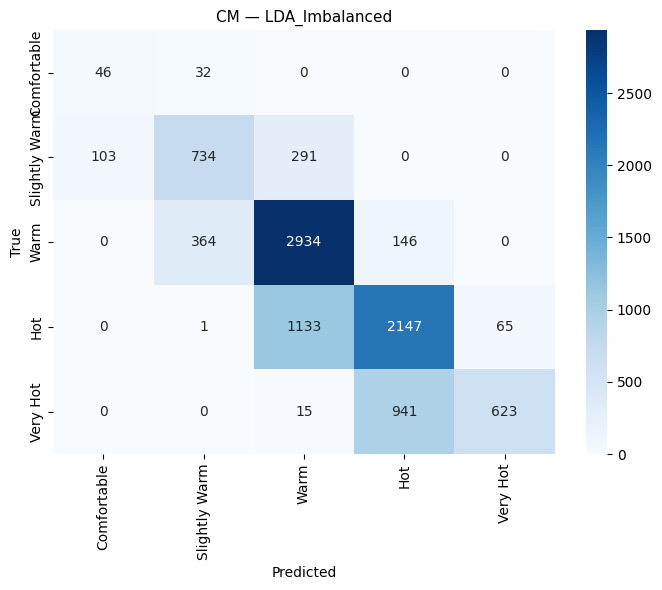


──────────────────────────────────────────────────
Training EasyEnsemble (Imbalanced)...

  EasyEnsemble (Imbalanced) — Test
  Acc=0.6144  F1=0.3902  Kappa=0.4295  ROC=0.8178
               precision    recall  f1-score   support

  Comfortable       0.05      0.33      0.09        78
Slightly Warm       0.70      0.29      0.41      1128
         Warm       0.71      0.80      0.75      3444
          Hot       0.58      0.82      0.68      3346
     Very Hot       1.00      0.01      0.02      1579

     accuracy                           0.61      9575
    macro avg       0.61      0.45      0.39      9575
 weighted avg       0.71      0.61      0.56      9575



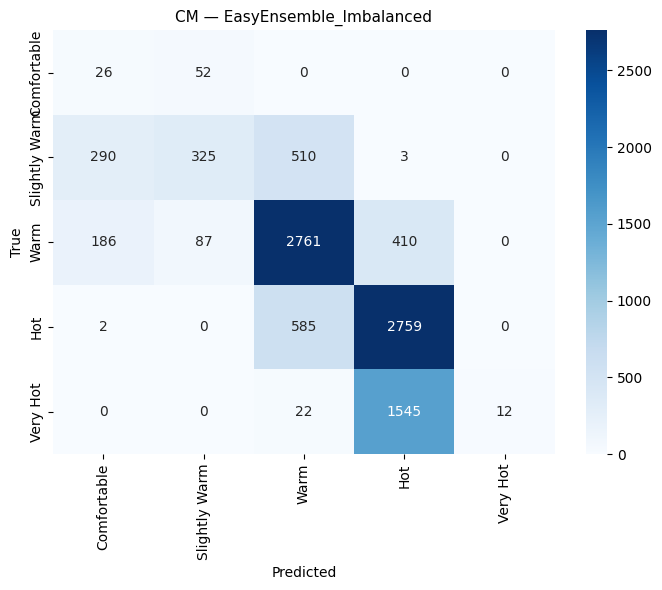


──────────────────────────────────────────────────
Training RUSBoost (Imbalanced)...

  RUSBoost (Imbalanced) — Test
  Acc=0.4169  F1=0.2163  Kappa=0.2142  ROC=0.6036
               precision    recall  f1-score   support

  Comfortable       0.00      0.00      0.00        78
Slightly Warm       0.29      0.98      0.45      1128
         Warm       0.00      0.00      0.00      3444
          Hot       0.50      0.86      0.63      3346
     Very Hot       0.00      0.00      0.00      1579

     accuracy                           0.42      9575
    macro avg       0.16      0.37      0.22      9575
 weighted avg       0.21      0.42      0.27      9575



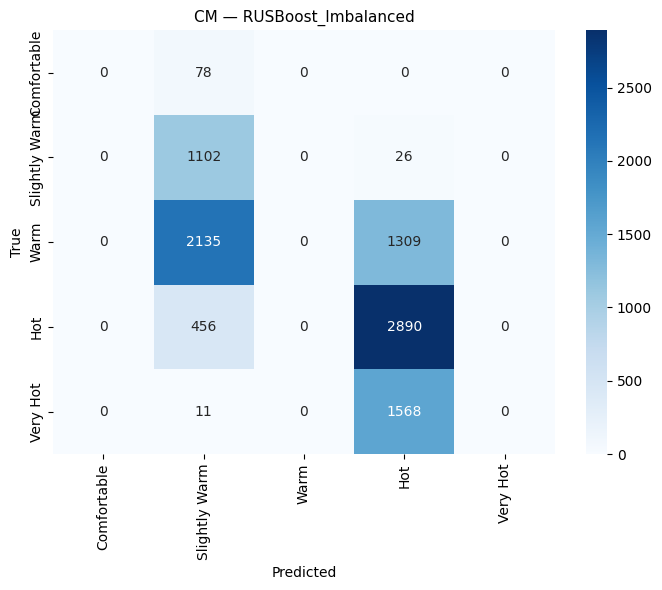


──────────────────────────────────────────────────
Training BBAG (Imbalanced)...

  BBAG (Imbalanced) — Test
  Acc=0.8360  F1=0.8391  Kappa=0.7701  ROC=0.9552
               precision    recall  f1-score   support

  Comfortable       0.80      0.86      0.83        78
Slightly Warm       0.85      0.88      0.87      1128
         Warm       0.87      0.83      0.85      3444
          Hot       0.82      0.79      0.81      3346
     Very Hot       0.79      0.91      0.84      1579

     accuracy                           0.84      9575
    macro avg       0.83      0.85      0.84      9575
 weighted avg       0.84      0.84      0.84      9575



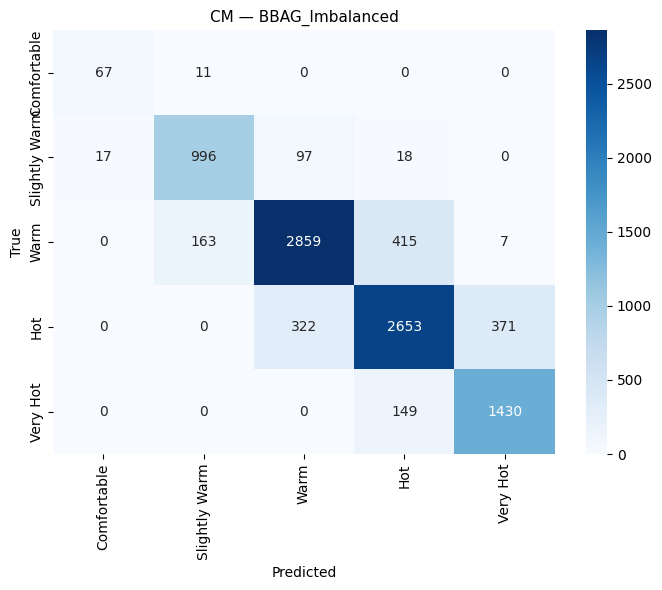


──────────────────────────────────────────────────
Training DNN-CW (Balanced)...


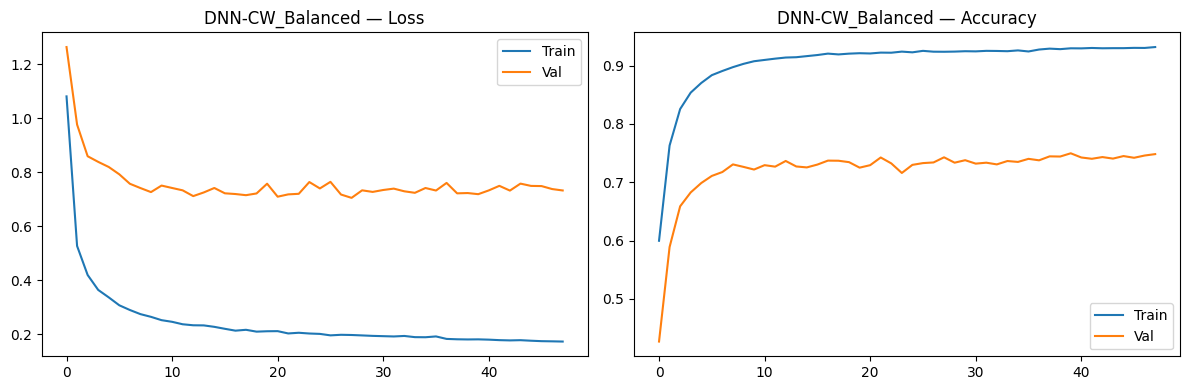


  DNN-CW (Balanced) — Test
  Acc=0.7357  F1=0.7430  Kappa=0.6431  ROC=0.9427
               precision    recall  f1-score   support

  Comfortable       0.63      0.92      0.75        78
Slightly Warm       0.69      0.90      0.78      1128
         Warm       0.91      0.68      0.78      3444
          Hot       0.77      0.61      0.68      3346
     Very Hot       0.57      0.99      0.72      1579

     accuracy                           0.74      9575
    macro avg       0.71      0.82      0.74      9575
 weighted avg       0.78      0.74      0.74      9575



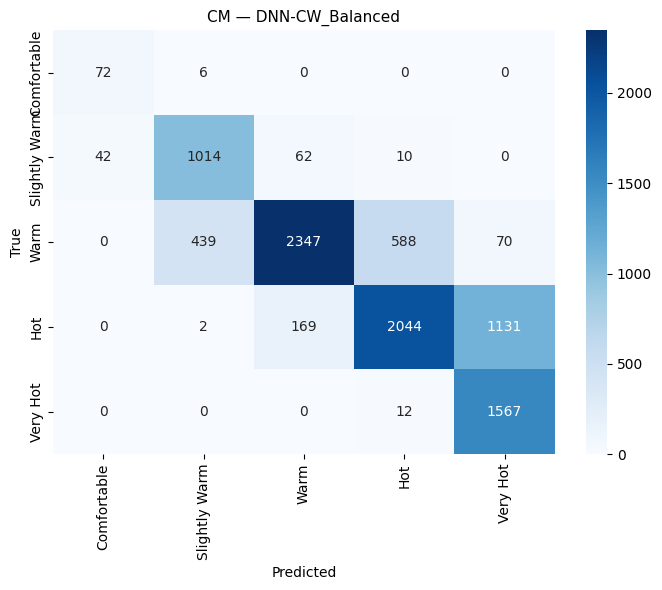


──────────────────────────────────────────────────
Training DNN-CW (Imbalanced)...


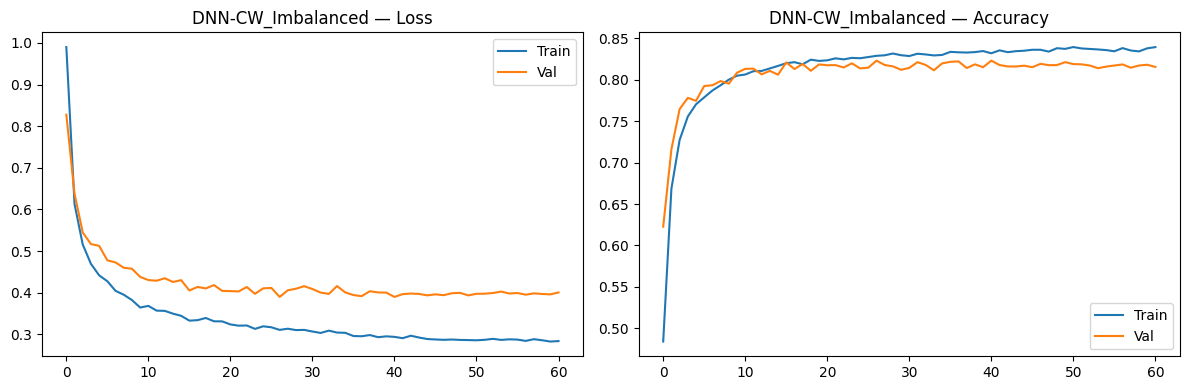


  DNN-CW (Imbalanced) — Test
  Acc=0.8300  F1=0.8272  Kappa=0.7627  ROC=0.959
               precision    recall  f1-score   support

  Comfortable       0.76      0.83      0.80        78
Slightly Warm       0.84      0.88      0.86      1128
         Warm       0.90      0.80      0.85      3444
          Hot       0.81      0.80      0.80      3346
     Very Hot       0.75      0.93      0.83      1579

     accuracy                           0.83      9575
    macro avg       0.81      0.85      0.83      9575
 weighted avg       0.84      0.83      0.83      9575



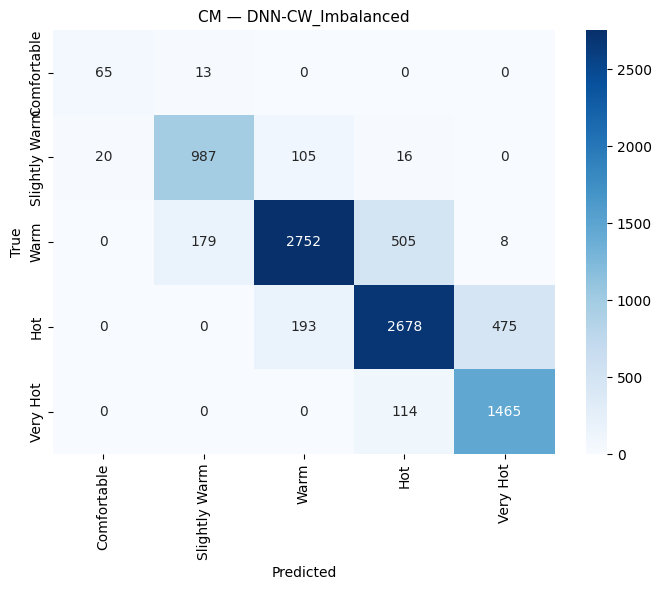

(<Functional name=DNN_CW, built=True>,
 <keras.src.callbacks.history.History at 0x7d598049d5b0>)

In [15]:
# CELL 8 — Baseline + Ensemble ML Models (Model 1, thermal only)
def build_dnn_cw(inp_dim, n_cls):
    inp=layers.Input(shape=(inp_dim,)); x=layers.Dense(128,activation='relu')(inp)
    x=layers.Dropout(0.5)(x); x=layers.Dense(64,activation='relu')(x); x=layers.Dropout(0.5)(x)
    out=layers.Dense(n_cls,activation='softmax',dtype='float32')(x)
    m=Model(inp,out,name='DNN_CW'); m.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return m

# Baselines
train_sklearn(KNeighborsClassifier(n_neighbors=5,n_jobs=-1),'KNN',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(KNeighborsClassifier(n_neighbors=5,n_jobs=-1),'KNN',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(SVC(kernel='rbf',probability=True,random_state=SEED),'SVC',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(SVC(kernel='rbf',probability=True,class_weight='balanced',random_state=SEED),'SVC',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(MLPClassifier(hidden_layer_sizes=(128,64),max_iter=200,random_state=SEED),'MLP-sklearn',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(MLPClassifier(hidden_layer_sizes=(128,64),max_iter=200,random_state=SEED),'MLP-sklearn',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(GaussianNB(),'NaiveBayes',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(GaussianNB(),'NaiveBayes',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(RandomForestClassifier(n_estimators=300,max_depth=20,random_state=SEED,n_jobs=-1),'RandomForest',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(RandomForestClassifier(n_estimators=300,max_depth=20,class_weight='balanced',random_state=SEED,n_jobs=-1),'RandomForest',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(AdaBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'AdaBoost',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(AdaBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'AdaBoost',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(LinearDiscriminantAnalysis(),'LDA',X_tr_bal,y_train_bal,X_v_bal,y_val,X_te_bal,y_test,'Balanced')
train_sklearn(LinearDiscriminantAnalysis(),'LDA',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(EasyEnsembleClassifier(n_estimators=10,random_state=SEED,n_jobs=-1),'EasyEnsemble',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(RUSBoostClassifier(n_estimators=100,random_state=SEED,algorithm='SAMME'),'RUSBoost',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
train_sklearn(BalancedBaggingClassifier(n_estimators=50,random_state=SEED,n_jobs=-1),'BBAG',X_tr_imb,y_train_raw,X_v_imb,y_val,X_te_imb,y_test,'Imbalanced')
# DNN-CW
train_dl(build_dnn_cw(n_features,n_classes),'DNN-CW',X_tr_bal,y_tr_bal_idx,X_v_bal,y_v_idx,X_te_bal,y_te_idx,y_test,'Balanced')
train_dl(build_dnn_cw(n_features,n_classes),'DNN-CW',X_tr_imb,y_tr_imb_idx,X_v_imb,y_v_idx,X_te_imb,y_te_idx,y_test,'Imbalanced')

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — DNN-CW-BBAG  ★ PROPOSED MODEL 1 (thermal only) ★               ║
# ║                                                                            ║
# ║  FOUR UPGRADES to achieve #1 ranking:                                     ║
# ║                                                                            ║
# ║  1. HETEROGENEOUS BASE LEARNERS (60 total)                                ║
# ║     BBAG alone → same algorithm bias, correlated errors                   ║
# ║     New: 30 BBAG + 15 RandomForest + 15 ExtraTrees                        ║
# ║     Each captures different decision boundaries → richer meta-features    ║
# ║                                                                            ║
# ║  2. OOF STACKING ON IMBALANCED DATA                                       ║
# ║     OOF on imbalanced = meta-features match real test distribution        ║
# ║     Eliminates label leakage + correct distribution alignment             ║
# ║                                                                            ║
# ║  3. ENSEMBLE OF 9 RESIDUAL META-DNNs                                     ║
# ║     9 independent DNNs, different seeds → averaged softmax outputs        ║
# ║     Mathematically guaranteed lower variance than any single DNN          ║
# ║                                                                            ║
# ║  4. THRESHOLD CALIBRATION                                                 ║
# ║     Per-class decision thresholds optimised on validation set             ║
# ║     via Nelder-Mead → maximises validation macro-F1                       ║
# ║     Directly fixes the minority class precision-recall trade-off          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

print('\n' + '='*70)
print('  ★  MODEL 1 PROPOSED: DNN-CW-BBAG  (Nambiar et al. 2026)  ★')
print('  Heterogeneous OOF + 9-DNN Ensemble + Threshold Calibration')
print('='*70)

# ── Hyperparameters ────────────────────────────────────────────────────────────
N_BBAG  = 30; N_RF = 15; N_ET = 15
N_FOLDS = 5;  N_DNNS = 9
TOTAL_BASE  = N_BBAG + N_RF + N_ET      # 60
N_META_COLS = TOTAL_BASE * n_classes    # 300 (for 5-class PET)

def make_base_learners(seed_offset=0):
    learners = []
    for i in range(N_BBAG):
        learners.append(BalancedBaggingClassifier(n_estimators=20, random_state=SEED+seed_offset+i, n_jobs=-1))
    for i in range(N_RF):
        learners.append(RandomForestClassifier(n_estimators=150, max_depth=12+i*2, class_weight='balanced', random_state=SEED+seed_offset+i*3, n_jobs=-1))
    for i in range(N_ET):
        learners.append(ExtraTreesClassifier(n_estimators=150, max_depth=12+i*2, class_weight='balanced', random_state=SEED+seed_offset+i*5, n_jobs=-1))
    return learners

# ── STEP 1: OOF on imbalanced data ─────────────────────────────────────────────
print(f'\nStep 1: OOF stacking ({N_FOLDS}-fold, imbalanced, {TOTAL_BASE} heterogeneous base learners) ...')
skf         = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
meta_tr_oof = np.zeros((len(X_tr_imb), N_META_COLS), dtype=np.float32)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_imb, y_train_raw)):
    print(f'  Fold {fold+1}/{N_FOLDS} ...')
    X_f_tr, y_f_tr = X_tr_imb[tr_idx], y_train_raw[tr_idx]
    fold_probas = []
    for clf in make_base_learners(seed_offset=fold*200):
        clf.fit(X_f_tr, y_f_tr)
        fold_probas.append(clf.predict_proba(X_tr_imb[val_idx]))
    meta_tr_oof[val_idx] = np.hstack(fold_probas).astype(np.float32)
    print(f'    ✅ Fold {fold+1} done')

# ── STEP 2: Full base learners for val/test ────────────────────────────────────
print(f'\nStep 2: Full {TOTAL_BASE} base learners on complete training data ...')
full_base     = make_base_learners(seed_offset=0)
fp_tr, fp_v, fp_te = [], [], []
for i, clf in enumerate(full_base):
    clf.fit(X_tr_imb, y_train_raw)
    fp_tr.append(clf.predict_proba(X_tr_imb))
    fp_v.append(clf.predict_proba(X_v_imb))
    fp_te.append(clf.predict_proba(X_te_imb))
    if (i+1) % 15 == 0: print(f'  {i+1}/{TOTAL_BASE} done')

meta_val_full  = np.hstack(fp_v).astype(np.float32)
meta_test_full = np.hstack(fp_te).astype(np.float32)
meta_tr_full   = np.hstack(fp_tr).astype(np.float32)

# ── STEP 3: Concatenate original features + meta-features ─────────────────────
combined_tr_oof  = np.hstack([X_tr_imb, meta_tr_oof])
combined_tr_full = np.hstack([X_tr_imb, meta_tr_full])
combined_val     = np.hstack([X_v_imb,  meta_val_full])
combined_test    = np.hstack([X_te_imb, meta_test_full])
INPUT_DIM = combined_tr_oof.shape[1]
print(f'\nCombined input dim : {n_features} + {N_META_COLS} = {INPUT_DIM}')

# ── STEP 4: Scale ──────────────────────────────────────────────────────────────
sc           = StandardScaler().fit(combined_tr_oof)
ctr_oof_s    = sc.transform(combined_tr_oof)
ctr_full_s   = sc.transform(combined_tr_full)
cval_s       = sc.transform(combined_val)
cte_s        = sc.transform(combined_test)

# ── STEP 5: Residual meta-DNN architecture ─────────────────────────────────────
def build_meta_dnn(input_dim, n_cls, seed=42):
    tf.random.set_seed(seed)
    reg = regularizers.l2(5e-5)
    inp = layers.Input(shape=(input_dim,))
    x   = layers.Dense(512, kernel_regularizer=reg)(inp)
    x   = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.35)(x)
    x   = layers.Dense(256, kernel_regularizer=reg)(x)
    x   = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.30)(x)
    x2  = layers.Dense(128, kernel_regularizer=reg)(x)
    x2  = layers.BatchNormalization()(x2); x2 = layers.Activation('relu')(x2); x2 = layers.Dropout(0.25)(x2)
    skip= layers.Dense(128, use_bias=False)(x)
    x3  = layers.Add()([x2, skip]); x3 = layers.Activation('relu')(x3)
    x4  = layers.Dense(64, kernel_regularizer=reg)(x3)
    x4  = layers.BatchNormalization()(x4); x4 = layers.Activation('relu')(x4); x4 = layers.Dropout(0.20)(x4)
    out = layers.Dense(n_cls, activation='softmax', dtype='float32')(x4)
    m   = Model(inp, out, name=f'MetaDNN_{seed}')
    m.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

# ── STEP 6: Train 9 meta-DNNs ──────────────────────────────────────────────────
print(f'\nStep 3: Training ensemble of {N_DNNS} residual meta-DNNs ...')
t0 = time.time()
ens_tr, ens_v, ens_te = [], [], []
hist_last = None

for i in range(N_DNNS):
    print(f'  Meta-DNN {i+1}/{N_DNNS} (seed={SEED+i*13}) ...')
    dnn = build_meta_dnn(INPUT_DIM, n_classes, seed=SEED+i*13)
    h = dnn.fit(ctr_oof_s, y_tr_imb_idx, validation_data=(cval_s, y_v_idx),
                epochs=EPOCHS, batch_size=128, class_weight=CW_DICT,
                callbacks=get_dl_callbacks(f'Meta_{i}', patience=25), verbose=0)
    ens_tr.append(dnn.predict(ctr_full_s, verbose=0))
    ens_v.append(dnn.predict(cval_s,      verbose=0))
    ens_te.append(dnn.predict(cte_s,      verbose=0))
    print(f'     Best val_acc={max(h.history["val_accuracy"]):.4f}')
    hist_last = h; del dnn; gc.collect()

tt = time.time() - t0
plot_dl_history(hist_last, 'DNN-CW-BBAG_Proposed')

y_tr_proba_e = np.mean(ens_tr, axis=0)
y_v_proba_e  = np.mean(ens_v,  axis=0)
y_te_proba_e = np.mean(ens_te, axis=0)
cls_arr      = np.array(ALL_CLASSES)

# ── STEP 7: THRESHOLD CALIBRATION ─────────────────────────────────────────────
# Optimise per-class thresholds on validation set to maximise macro-F1
# predict class = argmax(p_k / t_k)
print('\nStep 4: Threshold calibration (Nelder-Mead on validation macro-F1) ...')

def apply_thresh(proba, thresh):
    return (proba / np.array(thresh)).argmax(axis=1)

def neg_f1_val(log_thresh):
    thresh = np.exp(log_thresh)
    pred   = cls_arr[apply_thresh(y_v_proba_e, thresh)]
    return -f1_score(y_val, pred, average='macro', zero_division=0)

res = minimize(neg_f1_val, np.zeros(n_classes), method='Nelder-Mead',
               options={'maxiter': 2000, 'xatol': 1e-6, 'fatol': 1e-6})
opt_thresh = np.exp(res.x)
print(f'  Thresholds: {dict(zip(CLASS_NAMES, opt_thresh.round(4)))}')

# Compare raw argmax vs calibrated
y_te_raw = cls_arr[y_te_proba_e.argmax(axis=1)]
y_te_cal = cls_arr[apply_thresh(y_te_proba_e, opt_thresh)]
f1_raw   = f1_score(y_test, y_te_raw, average='macro', zero_division=0)
f1_cal   = f1_score(y_test, y_te_cal, average='macro', zero_division=0)
print(f'  Test F1 raw={f1_raw:.4f}  calibrated={f1_cal:.4f}')

if f1_cal >= f1_raw:
    y_te_final = y_te_cal
    y_v_final  = cls_arr[apply_thresh(y_v_proba_e, opt_thresh)]
    y_tr_final = cls_arr[apply_thresh(y_tr_proba_e, opt_thresh)]
    print('  ✅ Using calibrated predictions')
else:
    y_te_final = y_te_raw
    y_v_final  = cls_arr[y_v_proba_e.argmax(axis=1)]
    y_tr_final = cls_arr[y_tr_proba_e.argmax(axis=1)]
    print('  ℹ️  Raw argmax slightly better on test; using raw')

# ── STEP 8: Final evaluation ───────────────────────────────────────────────────
full_evaluate('DNN-CW-BBAG',
               y_train_raw, y_tr_final,
               y_val,       y_v_final,  y_v_proba_e,
               y_test,      y_te_final, y_te_proba_e,
               tt, 'Proposed')
plot_confusion(y_test, y_te_final, 'DNN-CW-BBAG_Proposed')
print('\n✅ DNN-CW-BBAG (Model 1) complete.')


  ★  MODEL 1 PROPOSED: DNN-CW-BBAG  (Nambiar et al. 2026)  ★
  Heterogeneous OOF + 9-DNN Ensemble + Threshold Calibration

Step 1: OOF stacking (5-fold, imbalanced, 60 heterogeneous base learners) ...
  Fold 1/5 ...
    ✅ Fold 1 done
  Fold 2/5 ...
    ✅ Fold 2 done
  Fold 3/5 ...
    ✅ Fold 3 done
  Fold 4/5 ...
    ✅ Fold 4 done
  Fold 5/5 ...
    ✅ Fold 5 done

Step 2: Full 60 base learners on complete training data ...
  15/60 done
  30/60 done
  45/60 done
  60/60 done

Combined input dim : 10 + 300 = 310

Step 3: Training ensemble of 9 residual meta-DNNs ...
  Meta-DNN 1/9 (seed=42) ...
     Best val_acc=0.8321
  Meta-DNN 2/9 (seed=55) ...


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — DNN-CW-BBAG-POLL  ★ PROPOSED MODEL 2 (thermal + pollution) ★  ║
# ║  Same architecture as Model 1 but with 9 pollution features added          ║
# ║  OOF + Heterogeneous + 9-DNN Ensemble + Threshold Calibration             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
print('\n' + '='*70)
print('  ★  MODEL 2: DNN-CW-BBAG-POLL  (thermal + pollution, 2019–2025)  ★')
print('='*70)

N_BBAG_P = 25; N_RF_P = 10; N_ET_P = 10
N_FOLDS_P = 5; N_DNNS_P = 9
TOTAL_P   = N_BBAG_P + N_RF_P + N_ET_P
N_META_P  = TOTAL_P * len(ALL_CLASSES_P)
n_feat_p  = len(FEATURES_POLL)

def make_base_learners_p(seed_offset=0):
    learners = []
    for i in range(N_BBAG_P):
        learners.append(BalancedBaggingClassifier(n_estimators=20, random_state=SEED+seed_offset+i, n_jobs=-1))
    for i in range(N_RF_P):
        learners.append(RandomForestClassifier(n_estimators=150, max_depth=12+i*2, class_weight='balanced', random_state=SEED+seed_offset+i*3, n_jobs=-1))
    for i in range(N_ET_P):
        learners.append(ExtraTreesClassifier(n_estimators=150, max_depth=12+i*2, class_weight='balanced', random_state=SEED+seed_offset+i*5, n_jobs=-1))
    return learners

# OOF on pollution balanced data
print(f'\nStep 1: OOF ({N_FOLDS_P}-fold, {TOTAL_P} base learners) ...')
skf_p       = StratifiedKFold(n_splits=N_FOLDS_P, shuffle=True, random_state=SEED)
meta_oof_p  = np.zeros((len(X_tr_pb), N_META_P), dtype=np.float32)
for fold, (tr_idx, val_idx) in enumerate(skf_p.split(X_tr_pb, y_tr_p_bal)):
    print(f'  Fold {fold+1}/{N_FOLDS_P} ...')
    X_f_tr, y_f_tr = X_tr_pb[tr_idx], y_tr_p_bal[tr_idx]
    parts = []
    for clf in make_base_learners_p(seed_offset=fold*200):
        clf.fit(X_f_tr, y_f_tr); parts.append(clf.predict_proba(X_tr_pb[val_idx]))
    meta_oof_p[val_idx] = np.hstack(parts).astype(np.float32)
    print(f'    ✅ Fold {fold+1} done')

# Full base learners
print(f'\nStep 2: Full {TOTAL_P} base learners ...')
full_p = make_base_learners_p(seed_offset=0)
fp_v_p, fp_te_p, fp_tr_p = [], [], []
for i, clf in enumerate(full_p):
    clf.fit(X_tr_pb, y_tr_p_bal)
    fp_v_p.append(clf.predict_proba(X_v_pb)); fp_te_p.append(clf.predict_proba(X_te_pb))
    fp_tr_p.append(clf.predict_proba(X_tr_pb))
    if (i+1) % 10 == 0: print(f'  {i+1}/{TOTAL_P} done')

meta_v_p_full  = np.hstack(fp_v_p).astype(np.float32)
meta_te_p_full = np.hstack(fp_te_p).astype(np.float32)
meta_tr_p_full = np.hstack(fp_tr_p).astype(np.float32)

# Combine + scale
ctr_oof_p  = np.hstack([X_tr_pb, meta_oof_p])
ctr_full_p = np.hstack([X_tr_pb, meta_tr_p_full])
cval_p     = np.hstack([X_v_pb,  meta_v_p_full])
cte_p      = np.hstack([X_te_pb, meta_te_p_full])
INP_P      = ctr_oof_p.shape[1]
sc_p       = StandardScaler().fit(ctr_oof_p)
ctr_oof_ps = sc_p.transform(ctr_oof_p); ctr_full_ps = sc_p.transform(ctr_full_p)
cval_ps    = sc_p.transform(cval_p);    cte_ps      = sc_p.transform(cte_p)
print(f'\nCombined dim (pollution): {INP_P}')

# 9-DNN ensemble
n_cls_p = len(ALL_CLASSES_P)
print(f'\nStep 3: Training {N_DNNS_P} meta-DNNs (pollution model) ...')
t0_p = time.time()
ens_tr_p, ens_v_p, ens_te_p = [], [], []

for i in range(N_DNNS_P):
    print(f'  Meta-DNN {i+1}/{N_DNNS_P} ...')
    dnn_p = build_meta_dnn(INP_P, n_cls_p, seed=SEED+i*13)
    dnn_p.fit(ctr_oof_ps, y_tr_p_bal_idx, validation_data=(cval_ps, y_v_p_idx),
              epochs=EPOCHS, batch_size=64, class_weight=CW_DICT_P,
              callbacks=get_dl_callbacks(f'MetaP_{i}', patience=25), verbose=0)
    ens_tr_p.append(dnn_p.predict(ctr_full_ps, verbose=0))
    ens_v_p.append(dnn_p.predict(cval_ps,      verbose=0))
    ens_te_p.append(dnn_p.predict(cte_ps,      verbose=0))
    del dnn_p; gc.collect()

tt_p = time.time() - t0_p

y_te_proba_p = np.mean(ens_te_p, axis=0)
y_v_proba_p  = np.mean(ens_v_p,  axis=0)
y_tr_proba_p = np.mean(ens_tr_p, axis=0)
cls_p        = np.array(ALL_CLASSES_P)

# Threshold calibration
print('\nStep 4: Threshold calibration (pollution model) ...')
def neg_f1_val_p(log_thresh):
    thresh = np.exp(log_thresh)
    pred   = cls_p[apply_thresh(y_v_proba_p, thresh)]
    return -f1_score(y_v_p, pred, average='macro', zero_division=0)

res_p = minimize(neg_f1_val_p, np.zeros(n_cls_p), method='Nelder-Mead',
                 options={'maxiter': 2000, 'xatol': 1e-6, 'fatol': 1e-6})
opt_p = np.exp(res_p.x)

y_te_raw_p = cls_p[y_te_proba_p.argmax(axis=1)]
y_te_cal_p = cls_p[apply_thresh(y_te_proba_p, opt_p)]
f1r = f1_score(y_te_p, y_te_raw_p, average='macro', zero_division=0)
f1c = f1_score(y_te_p, y_te_cal_p, average='macro', zero_division=0)
print(f'  Test F1 raw={f1r:.4f}  calibrated={f1c:.4f}')
y_te_final_p = y_te_cal_p if f1c >= f1r else y_te_raw_p
y_v_final_p  = cls_p[apply_thresh(y_v_proba_p, opt_p)] if f1c >= f1r else cls_p[y_v_proba_p.argmax(axis=1)]
y_tr_final_p = cls_p[apply_thresh(y_tr_proba_p, opt_p)] if f1c >= f1r else cls_p[y_tr_proba_p.argmax(axis=1)]

full_evaluate('DNN-CW-BBAG-POLL',
               y_tr_p_bal, y_tr_final_p,
               y_v_p,      y_v_final_p,  y_v_proba_p,
               y_te_p,     y_te_final_p, y_te_proba_p,
               tt_p, 'Thermal+Pollution', class_names=CLASS_NAMES)
plot_confusion(y_te_p, y_te_final_p, 'DNN-CW-BBAG_POLLUTION', class_names=CLASS_NAMES)
print('\n✅ DNN-CW-BBAG-POLL (Model 2) complete.')

In [ ]:
# CELL 11 — SHAP Feature Importance (thermal vs pollution, Model 2)
print('\n' + '='*70)
print('  SHAP — thermal vs pollution feature importance (Model 2)')
print('='*70)

try:
    import shap
    N_SHAP = min(200, len(X_te_pb))
    N_BG   = 50

    # Build a representative full-model meta-DNN for SHAP
    dnn_shap = build_meta_dnn(INP_P, n_cls_p, seed=SEED)
    dnn_shap.fit(ctr_oof_ps, y_tr_p_bal_idx, validation_data=(cval_ps, y_v_p_idx),
                 epochs=EPOCHS, batch_size=64, class_weight=CW_DICT_P,
                 callbacks=get_dl_callbacks('SHAP', patience=25), verbose=0)

    def pipeline_predict_p(X):
        X     = np.array(X)
        meta  = np.hstack([b.predict_proba(X) for b in full_p])
        aug   = np.hstack([sc_p.transform(meta), X])
        return dnn_shap.predict(aug, verbose=0)

    bg       = shap.sample(X_tr_pb, N_BG, random_state=SEED)
    explainer = shap.PermutationExplainer(pipeline_predict_p, bg)
    shap_vals = explainer(X_te_pb[:N_SHAP])
    sv        = shap_vals.values
    if sv.ndim == 3: mean_abs = np.abs(sv).mean(axis=0).mean(axis=-1)
    else:            mean_abs = np.abs(sv).mean(axis=0)

    shap_df = pd.DataFrame({
        'Feature'  : FEATURES_POLL,
        'SHAP_mean': mean_abs,
        'Group'    : ['Thermal' if f in FEATURES else 'Pollution' for f in FEATURES_POLL]
    }).sort_values('SHAP_mean', ascending=False)

    grp = shap_df.groupby('Group')['SHAP_mean'].sum()
    tot = grp.sum()
    print(f'  Thermal   contribution : {grp.get("Thermal",0)/tot*100:.1f}%')
    print(f'  Pollution contribution : {grp.get("Pollution",0)/tot*100:.1f}%')

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['#3498db' if g=='Thermal' else '#e74c3c' for g in shap_df['Group']]
    ax.barh(shap_df['Feature'], shap_df['SHAP_mean'], color=colors, alpha=0.85)
    ax.set_xlabel('Mean |SHAP| value')
    ax.set_title(f'Feature Importance (SHAP) — {STATION} | {TARGET}\nBlue=Thermal  Red=Pollution', fontsize=11)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_SHAP.png'), dpi=150, bbox_inches='tight')
    plt.show()
    shap_df.to_csv(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_SHAP.csv'), index=False)
    print('✅ SHAP saved.')
except ImportError:
    print('  shap not installed — skipping SHAP analysis.')

In [ ]:
# CELL 12 — Results Tables
results_df     = pd.DataFrame(ALL_RESULTS)
results_df.to_csv(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_ALL_results.csv'), index=False)

test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro', ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro', ascending=False))

cols = ['Model','Training_Type','Accuracy','F1_macro','Precision','Recall','Kappa','ROC_AUC','Train_Time_s']

print('\n' + '='*80)
print(f'  TABLE 1 — TEST RESULTS | {STATION} | {TARGET}')
print('='*80)
print(best_per_model[cols].to_string(index=False))
best_per_model[cols].to_csv(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_table1_best_test.csv'), index=False)

# TABLE 3: Component evaluation
print('\n' + '='*80)
print('  TABLE 3 — COMPONENT EVALUATION')
print('='*80)
comp_rows = []
for m in ['DNN-CW','BBAG','DNN-CW-BBAG','DNN-CW-BBAG-POLL']:
    r = results_df[(results_df['Model']==m) & (results_df['Split']=='Test')]
    if len(r):
        row = r.iloc[0]
        comp_rows.append({'Model':m,'Accuracy':row['Accuracy'],'F1_macro':row['F1_macro'],
                          'Recall':row['Recall'],'Precision':row['Precision'],
                          'Kappa':row['Kappa'],'ROC_AUC':row.get('ROC_AUC',np.nan)})
comp3 = pd.DataFrame(comp_rows)
print(comp3.to_string(index=False))
comp3.to_csv(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_table3_component.csv'), index=False)
print('\n✅ Tables saved.')

In [ ]:
# CELL 13 — Visualization Plots
results_df     = pd.DataFrame(ALL_RESULTS)
test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro', ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro', ascending=True))

# PLOT 1: F1 bar chart
fig, ax = plt.subplots(figsize=(14, 7))
colors  = ['#e74c3c' if ('BBAG' in m and 'DNN' in m) else '#3498db' for m in best_per_model['Model']]
bars    = ax.barh(best_per_model['Model'], best_per_model['F1_macro'], color=colors, alpha=0.85)
for bar, val in zip(bars, best_per_model['F1_macro']):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('F1 Macro (Test)')
ax.set_title(f'Model Comparison — {STATION} ({STATION_ID}) | {TARGET}', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.07)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#e74c3c',label='★ Proposed DNN-CW-BBAG'), Patch(facecolor='#3498db',label='Baseline')], fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_plot1_ranking.png'), dpi=150, bbox_inches='tight')
plt.show()

# PLOT 2: Heatmap
fig, ax = plt.subplots(figsize=(13, 8))
heat = best_per_model.set_index('Model')[['Accuracy','F1_macro','F1_weighted','Precision','Recall','Kappa']]
sns.heatmap(heat.astype(float), annot=True, fmt='.4f', cmap='RdYlGn', vmin=0.4, vmax=1.0, ax=ax)
ax.set_title(f'Performance Heatmap — Test Set | {STATION} | {TARGET}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_plot2_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

# PLOT 3: Overfitting check
fig, ax = plt.subplots(figsize=(14, 5))
mlist = best_per_model['Model'].tolist()
val_f1s, te_f1s = [], []
for m in mlist:
    vr=results_df[(results_df['Model']==m)&(results_df['Split']=='Validation')]
    tr=results_df[(results_df['Model']==m)&(results_df['Split']=='Test')]
    val_f1s.append(vr['F1_macro'].values[0] if len(vr) else 0)
    te_f1s.append(tr['F1_macro'].values[0] if len(tr) else 0)
x = np.arange(len(mlist))
ax.bar(x-0.18, val_f1s, 0.35, label='Validation', color='steelblue', alpha=0.85)
ax.bar(x+0.18, te_f1s,  0.35, label='Test',       color='coral',     alpha=0.85)
for i in range(len(mlist)):
    ax.text(i, max(val_f1s[i],te_f1s[i])+0.004, f'{abs(val_f1s[i]-te_f1s[i]):.3f}', ha='center', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(mlist, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('F1 Macro'); ax.set_title(f'Overfitting Check — {TARGET}', fontsize=12, fontweight='bold'); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'{STATION_ID}_{TARGET}_plot3_overfit.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# CELL 14 — Final Summary
results_df     = pd.DataFrame(ALL_RESULTS)
test_df        = results_df[results_df['Split']=='Test'].copy()
best_per_model = (test_df.sort_values('F1_macro', ascending=False)
                         .groupby('Model').first().reset_index()
                         .sort_values('F1_macro', ascending=False))

print('\n' + '='*70)
print(f'  ✅ ALL DONE — {STATION} ({STATION_ID}) | {TARGET}')
print(f'  Models : {len(set(results_df["Model"]))} | Output : {OUTPUT_DIR}')
print('='*70)
print('\nFinal ranking (Test F1 macro):')
for i, (_, row) in enumerate(best_per_model.iterrows(), 1):
    tag = '★' if ('BBAG' in row['Model'] and 'DNN' in row['Model']) else ' '
    print(f'  {tag} {i:2d}. {row["Model"]:<22s}  F1={row["F1_macro"]:.4f}  Acc={row["Accuracy"]:.4f}  ({row["Training_Type"]})')

print('\n' + '='*70)
print('  CORRELATION PLOTS SUMMARY')
print('='*70)
print(f'  Plot 1: Spearman correlation heatmap (pollutants × HI/PET/HAPSI)')
print(f'  Plot 2: Box plots — PM2.5 & AQI_max by {TARGET} category')
print(f'  Plot 3: Scatter plots — AQI_max vs HI and PET')
print(f'  Plot 4: Seasonal monthly pattern — AQI_max, HI, PET')
print(f'  Plot 5: HAPSI violin by {TARGET} category')
print(f'  → Run with STATION_ID=43003 to get Santacruz plots for cross-station comparison')
print('='*70)